In [97]:
import pandas as pd
import numpy as np
import os

In [98]:
DATA_PATH = "../data/raw"

print(os.listdir(DATA_PATH))


['PdM_errors.csv', 'PdM_failures.csv', 'PdM_machines.csv', 'PdM_maint.csv', 'PdM_telemetry.csv']


In [99]:
telemetry = pd.read_csv(f"{DATA_PATH}/PdM_telemetry.csv")
errors = pd.read_csv(f"{DATA_PATH}/PdM_errors.csv")
failures = pd.read_csv(f"{DATA_PATH}/PdM_failures.csv")
maintenance = pd.read_csv(f"{DATA_PATH}/PdM_maint.csv")
machines = pd.read_csv(f"{DATA_PATH}/PdM_machines.csv")

In [100]:
print("Telemetry:", telemetry.shape)
print("Errors:", errors.shape)
print("Failures:", failures.shape)
print("Maintenance:", maintenance.shape)
print("Machines:", machines.shape)

Telemetry: (876100, 6)
Errors: (3919, 3)
Failures: (761, 3)
Maintenance: (3286, 3)
Machines: (100, 3)


In [101]:
display(telemetry.head())

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [102]:
display(errors.head())

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [103]:
display(failures.head())

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


In [104]:
display(maintenance.head())

,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


In [105]:
display(machines.head())

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


In [106]:
datasets = {
    "Telemetry": telemetry,
    "Errors": errors,
    "Failures": failures,
    "Maintenance": maintenance,
    "Machines": machines
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    print("Columns:", list(df.columns))
    print("Shape:", df.shape)


Telemetry
Columns: ['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration']
Shape: (876100, 6)

Errors
Columns: ['datetime', 'machineID', 'errorID']
Shape: (3919, 3)

Failures
Columns: ['datetime', 'machineID', 'failure']
Shape: (761, 3)

Maintenance
Columns: ['datetime', 'machineID', 'comp']
Shape: (3286, 3)

Machines
Columns: ['machineID', 'model', 'age']
Shape: (100, 3)


In [107]:
# Check missing values

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Telemetry
datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

Errors
datetime     0
machineID    0
errorID      0
dtype: int64

Failures
datetime     0
machineID    0
failure      0
dtype: int64

Maintenance
datetime     0
machineID    0
comp         0
dtype: int64

Machines
machineID    0
model        0
age          0
dtype: int64


In [108]:
print("Machines in telemetry:", telemetry["machineID"].nunique())
print("Machines in errors:", errors["machineID"].nunique())
print("Machines in failures:", failures["machineID"].nunique())
print("Machines in maintenance:", maintenance["machineID"].nunique())
print("Machines table:", machines["machineID"].nunique())

Machines in telemetry: 100
Machines in errors: 100
Machines in failures: 98
Machines in maintenance: 100
Machines table: 100


In [109]:
for name, df in datasets.items():
    if "datetime" in df.columns:
        print(
            f"{name}:",
            df["datetime"].min(),
            "→",
            df["datetime"].max()
        )

Telemetry: 2015-01-01 06:00:00 → 2016-01-01 06:00:00
Errors: 2015-01-01 06:00:00 → 2016-01-01 05:00:00
Failures: 2015-01-02 03:00:00 → 2015-12-31 06:00:00
Maintenance: 2014-06-01 06:00:00 → 2016-01-01 06:00:00


In [110]:
print("Failure types:")
print(failures["failure"].value_counts())

Failure types:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64


In [111]:
print("Error types:")
print(errors["errorID"].value_counts())

Error types:
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64


In [112]:
print("Maintenance components:")
print(maintenance["comp"].value_counts())

Maintenance components:
comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64


In [113]:
print("Total failure events:", len(failures))
print("Total error events:", len(errors))
print("Total maintenance events:", len(maintenance))

Total failure events: 761
Total error events: 3919
Total maintenance events: 3286


In [114]:
for name, df in datasets.items():
    print(f"{name}:")
    print(df.dtypes)
    print()

Telemetry:
datetime         str
machineID      int64
volt         float64
rotate       float64
pressure     float64
vibration    float64
dtype: object

Errors:
datetime       str
machineID    int64
errorID        str
dtype: object

Failures:
datetime       str
machineID    int64
failure        str
dtype: object

Maintenance:
datetime       str
machineID    int64
comp           str
dtype: object

Machines:
machineID    int64
model          str
age          int64
dtype: object



In [115]:
for df in datasets.values():
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])

In [116]:
print(telemetry.dtypes)

datetime     datetime64[us]
machineID             int64
volt                float64
rotate              float64
pressure            float64
vibration           float64
dtype: object


In [117]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Telemetry: 0 duplicate rows
Errors: 0 duplicate rows
Failures: 0 duplicate rows
Maintenance: 0 duplicate rows
Machines: 0 duplicate rows


In [118]:
telemetry_ml = telemetry.copy()
failures_ml = failures.copy()

telemetry_ml = telemetry_ml.sort_values(["machineID", "datetime"]).reset_index(drop=True)
failures_ml = failures_ml.sort_values(["machineID", "datetime"]).reset_index(drop=True)

In [119]:
telemetry_ml = pd.merge_asof(
    telemetry_ml.sort_values("datetime"),
    failures_ml[["machineID", "datetime"]]
        .rename(columns={"datetime": "failure_time"})
        .sort_values("failure_time"),
    left_on="datetime",
    right_on="failure_time",
    by="machineID",
    direction="forward"
)

In [120]:
display(telemetry_ml.head())

,datetime,machineID,volt,rotate,pressure,vibration,failure_time
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,2015-01-05 06:00:00
1,2015-01-01 06:00:00,53,183.084582,420.980061,109.235805,45.737760,2015-03-29 06:00:00
2,2015-01-01 06:00:00,99,168.596133,384.747105,110.921131,41.944692,2015-01-02 03:00:00
3,2015-01-01 06:00:00,12,171.404215,576.923563,97.145400,47.725909,2015-01-07 06:00:00
4,2015-01-01 06:00:00,6,136.878588,492.088420,149.003582,22.973289,NaT


In [121]:
telemetry_ml["hours_to_failure"] = (
    telemetry_ml["failure_time"] - telemetry_ml["datetime"]
).dt.total_seconds() / 3600

In [122]:
display(
    telemetry_ml[
        telemetry_ml["hours_to_failure"].notna()
    ][
        ["machineID", "datetime", "failure_time", "hours_to_failure"]
    ].head(20)
)

,machineID,datetime,failure_time,hours_to_failure
0,1,2015-01-01 06:00:00,2015-01-05 06:00:00,96.0
1,53,2015-01-01 06:00:00,2015-03-29 06:00:00,2088.0
2,99,2015-01-01 06:00:00,2015-01-02 03:00:00,21.0
3,12,2015-01-01 06:00:00,2015-01-07 06:00:00,144.0
5,69,2015-01-01 06:00:00,2015-01-05 06:00:00,96.0
6,57,2015-01-01 06:00:00,2015-02-07 06:00:00,888.0
7,23,2015-01-01 06:00:00,2015-01-05 06:00:00,96.0
8,71,2015-01-01 06:00:00,2015-01-11 06:00:00,240.0
9,2,2015-01-01 06:00:00,2015-03-19 06:00:00,1848.0
10,63,2015-01-01 06:00:00,2015-01-28 06:00:00,648.0


In [123]:
display(
    telemetry_ml[
        telemetry_ml["machineID"] == 1
    ][
        ["machineID", "datetime", "failure_time", "hours_to_failure"]
    ].head(120)
)

,machineID,datetime,failure_time,hours_to_failure
0,1,2015-01-01 06:00:00,2015-01-05 06:00:00,96.0
168,1,2015-01-01 07:00:00,2015-01-05 06:00:00,95.0
241,1,2015-01-01 08:00:00,2015-01-05 06:00:00,94.0
398,1,2015-01-01 09:00:00,2015-01-05 06:00:00,93.0
419,1,2015-01-01 10:00:00,2015-01-05 06:00:00,92.0
...,...,...,...,...
11596,1,2015-01-06 01:00:00,2015-03-06 06:00:00,1421.0
11634,1,2015-01-06 02:00:00,2015-03-06 06:00:00,1420.0
11753,1,2015-01-06 03:00:00,2015-03-06 06:00:00,1419.0
11847,1,2015-01-06 04:00:00,2015-03-06 06:00:00,1418.0


In [124]:
telemetry_ml["failure_next_24h"] = (
    (telemetry_ml["hours_to_failure"] > 0) &
    (telemetry_ml["hours_to_failure"] <= 24)
).astype(int)

In [125]:
print(telemetry_ml["failure_next_24h"].value_counts())

failure_next_24h
0    858917
1     17183
Name: count, dtype: int64


In [126]:
print(
    telemetry_ml["failure_next_24h"]
    .value_counts(normalize=True) * 100
)

failure_next_24h
0    98.038694
1     1.961306
Name: proportion, dtype: float64


In [127]:
display(
    telemetry_ml[
        (telemetry_ml["machineID"] == 1) &
        (telemetry_ml["hours_to_failure"].between(0, 30))
    ][
        ["machineID", "datetime", "failure_time",
         "hours_to_failure", "failure_next_24h"]
    ]
)

,machineID,datetime,failure_time,hours_to_failure,failure_next_24h
6623,1,2015-01-04 00:00:00,2015-01-05 06:00:00,30.0,0
6743,1,2015-01-04 01:00:00,2015-01-05 06:00:00,29.0,0
6868,1,2015-01-04 02:00:00,2015-01-05 06:00:00,28.0,0
6922,1,2015-01-04 03:00:00,2015-01-05 06:00:00,27.0,0
7053,1,2015-01-04 04:00:00,2015-01-05 06:00:00,26.0,0
...,...,...,...,...,...
837229,1,2015-12-16 02:00:00,2015-12-16 06:00:00,4.0,1
837331,1,2015-12-16 03:00:00,2015-12-16 06:00:00,3.0,1
837480,1,2015-12-16 04:00:00,2015-12-16 06:00:00,2.0,1
837552,1,2015-12-16 05:00:00,2015-12-16 06:00:00,1.0,1


In [128]:
print(telemetry_ml["failure_next_24h"].value_counts())
print(telemetry_ml["failure_next_24h"].value_counts(normalize=True) * 100)

failure_next_24h
0    858917
1     17183
Name: count, dtype: int64
failure_next_24h
0    98.038694
1     1.961306
Name: proportion, dtype: float64


In [129]:
df = telemetry_ml.copy()

df = df.sort_values(
    ["machineID", "datetime"]
).reset_index(drop=True)

In [130]:
df.head()

,datetime,machineID,volt,rotate,pressure,vibration,failure_time,hours_to_failure,failure_next_24h
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,2015-01-05 06:00:00,96.0,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,2015-01-05 06:00:00,95.0,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,2015-01-05 06:00:00,94.0,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,2015-01-05 06:00:00,93.0,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,2015-01-05 06:00:00,92.0,0


In [131]:
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["dayofweek"] = df["datetime"].dt.dayofweek

In [132]:
sensor_cols = ["volt", "rotate", "pressure", "vibration"]

for col in sensor_cols:
    df[f"{col}_mean_6h"] = (
        df.groupby("machineID")[col]
        .transform(lambda x: x.rolling(6, min_periods=1).mean())
    )

    df[f"{col}_std_6h"] = (
        df.groupby("machineID")[col]
        .transform(lambda x: x.rolling(6, min_periods=1).std())
    )

In [133]:
for col in sensor_cols:
    df[f"{col}_change_1h"] = (
        df.groupby("machineID")[col]
        .diff(1)
    )

In [134]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(876100, 25)
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h']
datetime                    0
machineID                   0
volt                        0
rotate                      0
pressure                    0
vibration                   0
failure_time           120746
hours_to_failure       120746
failure_next_24h            0
hour                        0
day                         0
month                       0
dayofweek                   0
volt_mean_6h                0
volt_std_6h               100
rotate_mean_6h              0
rotate_std_6h             100
pressure_mean_6h            0
pressure_std_6h           100
vibration_mean_6h         

In [135]:
for col in sensor_cols:
    df[f"{col}_mean_24h"] = (
        df.groupby("machineID")[col]
        .transform(
            lambda x: x.rolling(24, min_periods=1).mean()
        )
    )

    df[f"{col}_std_24h"] = (
        df.groupby("machineID")[col]
        .transform(
            lambda x: x.rolling(24, min_periods=1).std()
        )
    )

In [136]:
for col in sensor_cols:
    df[f"{col}_change_24h"] = (
        df.groupby("machineID")[col].diff(24)
    )

In [137]:
print(df.shape)
print(df.columns.tolist())

(876100, 37)
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h']


In [138]:
df = df.merge(
    machines,
    on="machineID",
    how="left"
)

In [139]:
print(df.shape)
print(df[["machineID", "model", "age"]].head())

(876100, 39)
   machineID   model  age
0          1  model3   18
1          1  model3   18
2          1  model3   18
3          1  model3   18
4          1  model3   18


In [140]:
print(df["model"].value_counts())
print(df["age"].describe())

model
model3    306635
model4    280352
model2    148937
model1    140176
Name: count, dtype: int64
count    876100.000000
mean         11.330000
std           5.827619
min           0.000000
25%           6.750000
50%          12.000000
75%          16.000000
max          20.000000
Name: age, dtype: float64


In [141]:
for col in sensor_cols:
    df[f"{col}_mean_24h"] = (
        df.groupby("machineID")[col]
        .transform(
            lambda x: x.rolling(24, min_periods=1).mean()
        )
    )

    df[f"{col}_std_24h"] = (
        df.groupby("machineID")[col]
        .transform(
            lambda x: x.rolling(24, min_periods=1).std()
        )
    )

    df[f"{col}_change_24h"] = (
        df.groupby("machineID")[col].diff(24)
    )

In [142]:
df = df.merge(
    machines,
    on="machineID",
    how="left"
)

In [143]:
print(df.shape)
print(df.columns.tolist())
print(df[["machineID", "model", "age"]].head())
print(df.isnull().sum())

(876100, 41)
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model_x', 'age_x', 'model_y', 'age_y']


KeyError: "['model', 'age'] not in index"

In [ ]:
print(machines.columns.tolist())
print(machines.head())

['machineID', 'model', 'age']
   machineID   model  age
0          1  model3   18
1          2  model4    7
2          3  model3    8
3          4  model3    7
4          5  model3    2


In [ ]:
print(df.columns.tolist())

['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model_x', 'age_x', 'model_y', 'age_y']


In [ ]:
print(machines.columns.tolist())
print(machines.head())
print(df.columns.tolist())

['machineID', 'model', 'age']
   machineID   model  age
0          1  model3   18
1          2  model4    7
2          3  model3    8
3          4  model3    7
4          5  model3    2
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model_x', 'age_x', 'model_y', 'age_y']


In [ ]:
# Check which copies are identical
print((df["model_x"] == df["model_y"]).all())
print((df["age_x"] == df["age_y"]).all())

True
True


In [ ]:
# Keep one copy of model and age
df["model"] = df["model_x"]
df["age"] = df["age_x"]

# Remove duplicate columns
df = df.drop(columns=["model_x", "age_x", "model_y", "age_y"])

In [ ]:
print(df[["machineID", "model", "age"]].head())
print(df.columns.tolist())
print(df.shape)

   machineID   model  age
0          1  model3   18
1          1  model3   18
2          1  model3   18
3          1  model3   18
4          1  model3   18
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model', 'age']
(876100, 39)


In [ ]:
# Keep one copy of model and age
df["model"] = df["model_x"]
df["age"] = df["age_x"]

# Remove duplicate columns
df = df.drop(columns=["model_x", "age_x", "model_y", "age_y"])

print(df[["machineID", "model", "age"]].head())
print(df.shape)

KeyError: 'model_x'

In [ ]:
print(df[["machineID", "model", "age"]].head())
print(df.columns.tolist())

   machineID   model  age
0          1  model3   18
1          1  model3   18
2          1  model3   18
3          1  model3   18
4          1  model3   18
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model', 'age']


In [ ]:
maintenance_ml = maintenance.copy()

maintenance_ml = maintenance_ml.sort_values(
    ["machineID", "datetime"]
).reset_index(drop=True)

print(maintenance_ml.head())
print(maintenance_ml.columns.tolist())

             datetime  machineID   comp
0 2014-06-01 06:00:00          1  comp2
1 2014-07-16 06:00:00          1  comp4
2 2014-07-31 06:00:00          1  comp3
3 2014-12-13 06:00:00          1  comp1
4 2015-01-05 06:00:00          1  comp4
['datetime', 'machineID', 'comp']


In [ ]:
print(maintenance_ml.head())
print(maintenance_ml.columns.tolist())

             datetime  machineID   comp
0 2014-06-01 06:00:00          1  comp2
1 2014-07-16 06:00:00          1  comp4
2 2014-07-31 06:00:00          1  comp3
3 2014-12-13 06:00:00          1  comp1
4 2015-01-05 06:00:00          1  comp4
['datetime', 'machineID', 'comp']


In [ ]:
maintenance_ml["maintenance_count"] = (
    maintenance_ml
    .groupby("machineID")
    .cumcount() + 1
)

print(maintenance_ml.head(10))

             datetime  machineID   comp  maintenance_count
0 2014-06-01 06:00:00          1  comp2                  1
1 2014-07-16 06:00:00          1  comp4                  2
2 2014-07-31 06:00:00          1  comp3                  3
3 2014-12-13 06:00:00          1  comp1                  4
4 2015-01-05 06:00:00          1  comp4                  5
5 2015-01-05 06:00:00          1  comp1                  6
6 2015-01-20 06:00:00          1  comp3                  7
7 2015-01-20 06:00:00          1  comp1                  8
8 2015-02-04 06:00:00          1  comp4                  9
9 2015-02-04 06:00:00          1  comp3                 10


In [ ]:
maintenance_last = maintenance_ml[
    ["datetime", "machineID"]
].rename(
    columns={"datetime": "last_maintenance_time"}
)

maintenance_last = maintenance_last.sort_values(
    "last_maintenance_time"
).reset_index(drop=True)

df = df.sort_values("datetime").reset_index(drop=True)

df = pd.merge_asof(
    df,
    maintenance_last,
    left_on="datetime",
    right_on="last_maintenance_time",
    by="machineID",
    direction="backward"
)

In [ ]:
df["hours_since_maintenance"] = (
    df["datetime"] - df["last_maintenance_time"]
).dt.total_seconds() / 3600

In [ ]:
maintenance_count = maintenance_ml[
    ["datetime", "machineID", "maintenance_count"]
].copy()

maintenance_count = maintenance_count.sort_values(
    "datetime"
).reset_index(drop=True)

In [ ]:
df = pd.merge_asof(
    df.sort_values("datetime"),
    maintenance_count,
    on="datetime",
    by="machineID",
    direction="backward"
)

In [ ]:
df = df.rename(
    columns={"maintenance_count": "maintenance_count_total"}
)

In [ ]:
df["datetime_30d_ago"] = (
    df["datetime"] - pd.Timedelta(days=30)
)

In [ ]:
maintenance_30d = maintenance_count.rename(
    columns={
        "datetime": "maintenance_datetime_30d",
        "maintenance_count": "maintenance_count_30d_ago"
    }
)

maintenance_30d = maintenance_30d.sort_values(
    "maintenance_datetime_30d"
).reset_index(drop=True)

df = pd.merge_asof(
    df.sort_values("datetime_30d_ago"),
    maintenance_30d,
    left_on="datetime_30d_ago",
    right_on="maintenance_datetime_30d",
    by="machineID",
    direction="backward"
)

In [ ]:
df["maintenance_events_30d"] = (
    df["maintenance_count_total"]
    - df["maintenance_count_30d_ago"].fillna(0)
)

In [ ]:
df["datetime_90d_ago"] = (
    df["datetime"] - pd.Timedelta(days=90)
)

In [ ]:
maintenance_90d = maintenance_count.rename(
    columns={
        "datetime": "maintenance_datetime_90d",
        "maintenance_count": "maintenance_count_90d_ago"
    }
)

maintenance_90d = maintenance_90d.sort_values(
    "maintenance_datetime_90d"
).reset_index(drop=True)

df = pd.merge_asof(
    df.sort_values("datetime_90d_ago"),
    maintenance_90d,
    left_on="datetime_90d_ago",
    right_on="maintenance_datetime_90d",
    by="machineID",
    direction="backward"
)

In [ ]:
df["maintenance_events_90d"] = (
    df["maintenance_count_total"]
    - df["maintenance_count_90d_ago"].fillna(0)
)

In [ ]:
df = df.drop(
    columns=[
        "last_maintenance_time",
        "maintenance_count_total",
        "datetime_30d_ago",
        "maintenance_datetime_30d",
        "maintenance_count_30d_ago",
        "datetime_90d_ago",
        "maintenance_datetime_90d",
        "maintenance_count_90d_ago"
    ]
)

In [ ]:
print(
    df[
        [
            "machineID",
            "datetime",
            "hours_since_maintenance",
            "maintenance_events_30d",
            "maintenance_events_90d"
        ]
    ].head(20)
)

    machineID            datetime  hours_since_maintenance  \
0           1 2015-01-01 06:00:00                    456.0   
1          50 2015-01-01 06:00:00                   1536.0   
2          60 2015-01-01 06:00:00                   2256.0   
3          31 2015-01-01 06:00:00                   2256.0   
4          78 2015-01-01 06:00:00                    816.0   
5          14 2015-01-01 06:00:00                      0.0   
6          48 2015-01-01 06:00:00                     96.0   
7          40 2015-01-01 06:00:00                    816.0   
8          97 2015-01-01 06:00:00                   2616.0   
9          61 2015-01-01 06:00:00                   1536.0   
10          4 2015-01-01 06:00:00                    456.0   
11         89 2015-01-01 06:00:00                     96.0   
12         10 2015-01-01 06:00:00                   1896.0   
13         67 2015-01-01 06:00:00                      0.0   
14         88 2015-01-01 06:00:00                   2616.0   
15      

In [ ]:
print(
    df[
        [
            "hours_since_maintenance",
            "maintenance_events_30d",
            "maintenance_events_90d"
        ]
    ].describe()
)

       hours_since_maintenance  maintenance_events_30d  maintenance_events_90d
count            876100.000000           876100.000000           876100.000000
mean                263.621687                2.273947                6.386458
std                 322.139335                0.955371                2.197006
min                   0.000000               -1.000000                0.000000
25%                 102.000000                2.000000                5.000000
50%                 205.000000                2.000000                7.000000
75%                 309.000000                3.000000                8.000000
max                4079.000000                5.000000               11.000000


In [ ]:
print(df.shape)
print(df.isnull().sum())

(876100, 42)
datetime                        0
machineID                       0
volt                            0
rotate                          0
pressure                        0
vibration                       0
failure_time               120746
hours_to_failure           120746
failure_next_24h                0
hour                            0
day                             0
month                           0
dayofweek                       0
volt_mean_6h                    0
volt_std_6h                   100
rotate_mean_6h                  0
rotate_std_6h                 100
pressure_mean_6h                0
pressure_std_6h               100
vibration_mean_6h               0
vibration_std_6h              100
volt_change_1h                100
rotate_change_1h              100
pressure_change_1h            100
vibration_change_1h           100
volt_mean_24h                   0
volt_std_24h                  100
rotate_mean_24h                 0
rotate_std_24h                100
p

In [ ]:
print(df.shape)

print(
    df[
        [
            "machineID",
            "datetime",
            "hours_since_maintenance",
            "maintenance_events_30d",
            "maintenance_events_90d"
        ]
    ].head(20)
)

print(df.isnull().sum())

(876100, 42)
    machineID            datetime  hours_since_maintenance  \
0           1 2015-01-01 06:00:00                    456.0   
1          50 2015-01-01 06:00:00                   1536.0   
2          60 2015-01-01 06:00:00                   2256.0   
3          31 2015-01-01 06:00:00                   2256.0   
4          78 2015-01-01 06:00:00                    816.0   
5          14 2015-01-01 06:00:00                      0.0   
6          48 2015-01-01 06:00:00                     96.0   
7          40 2015-01-01 06:00:00                    816.0   
8          97 2015-01-01 06:00:00                   2616.0   
9          61 2015-01-01 06:00:00                   1536.0   
10          4 2015-01-01 06:00:00                    456.0   
11         89 2015-01-01 06:00:00                     96.0   
12         10 2015-01-01 06:00:00                   1896.0   
13         67 2015-01-01 06:00:00                      0.0   
14         88 2015-01-01 06:00:00                   2616.

In [ ]:
errors_ml = errors.copy()

errors_ml = errors_ml.sort_values(
    ["machineID", "datetime"]
).reset_index(drop=True)

print(errors_ml.head())
print(errors_ml.columns.tolist())

             datetime  machineID errorID
0 2015-01-03 07:00:00          1  error1
1 2015-01-03 20:00:00          1  error3
2 2015-01-04 06:00:00          1  error5
3 2015-01-10 15:00:00          1  error4
4 2015-01-22 10:00:00          1  error4
['datetime', 'machineID', 'errorID']


In [ ]:
errors_24h = (
    errors_ml
    .set_index("datetime")
    .groupby("machineID")["errorID"]
    .rolling("24h")
    .count()
    .reset_index()
)

errors_24h = errors_24h.rename(
    columns={"errorID": "errors_last_24h"}
)

In [ ]:
errors_7d = (
    errors_ml
    .set_index("datetime")
    .groupby("machineID")["errorID"]
    .rolling("7d")
    .count()
    .reset_index()
)

errors_7d = errors_7d.rename(
    columns={"errorID": "errors_last_7d"}
)

C:\Users\dhorj\AppData\Local\Temp\ipykernel_16308\1193292210.py:5: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .rolling("7d")


In [ ]:
errors_7d = (
    errors_ml
    .set_index("datetime")
    .groupby("machineID")["errorID"]
    .rolling("7D")
    .count()
    .reset_index()
)

errors_7d = errors_7d.rename(
    columns={"errorID": "errors_last_7d"}
)

In [ ]:
df = df.sort_values("datetime").reset_index(drop=True)

errors_24h = errors_24h.sort_values("datetime").reset_index(drop=True)
errors_7d = errors_7d.sort_values("datetime").reset_index(drop=True)

In [ ]:
df = pd.merge_asof(
    df,
    errors_24h,
    on="datetime",
    by="machineID",
    direction="backward"
)

In [ ]:
df = pd.merge_asof(
    df,
    errors_7d,
    on="datetime",
    by="machineID",
    direction="backward"
)

ValueError: right keys must be sorted

In [ ]:
last_error = errors_ml[
    ["datetime", "machineID"]
].rename(
    columns={"datetime": "last_error_time"}
)

last_error = last_error.sort_values(
    "last_error_time"
).reset_index(drop=True)

In [ ]:
df = pd.merge_asof(
    df.sort_values("datetime"),
    last_error,
    left_on="datetime",
    right_on="last_error_time",
    by="machineID",
    direction="backward"
)

In [ ]:
df["hours_since_error"] = (
    df["datetime"] - df["last_error_time"]
).dt.total_seconds() / 3600

In [ ]:
df = df.drop(columns=["last_error_time"])

In [ ]:
print(df.shape)

print(
    df[
        [
            "machineID",
            "datetime",
            "errors_last_24h",
            "errors_last_7d",
            "hours_since_error"
        ]
    ].head(20)
)

(876100, 44)


KeyError: "['errors_last_7d'] not in index"

In [ ]:
print(
    df[
        [
            "errors_last_24h",
            "errors_last_7d",
            "hours_since_error"
        ]
    ].describe()
)

       errors_last_24h  errors_last_7d  hours_since_error
count    854954.000000   854954.000000      854954.000000
mean          1.144746        1.740745         227.035773
std           0.388402        0.929385         221.864581
min           1.000000        1.000000           0.000000
25%           1.000000        1.000000          67.000000
50%           1.000000        1.000000         161.000000
75%           1.000000        2.000000         315.000000
max           4.000000        7.000000        1909.000000


In [ ]:
print(
    df[
        [
            "errors_last_24h",
            "errors_last_7d",
            "hours_since_error"
        ]
    ].isnull().sum()
)

errors_last_24h      21146
errors_last_7d       21146
hours_since_error    21146
dtype: int64


In [ ]:
import numpy as np

# Make sure both datasets are sorted
df = df.sort_values(["machineID", "datetime"]).reset_index(drop=True)
errors_ml = errors_ml.sort_values(["machineID", "datetime"]).reset_index(drop=True)

# Create empty arrays
errors_24h_values = np.zeros(len(df))
errors_7d_values = np.zeros(len(df))

# Calculate separately for each machine
for machine_id, telemetry_group in df.groupby("machineID"):
    
    error_times = (
        errors_ml.loc[
            errors_ml["machineID"] == machine_id,
            "datetime"
        ]
        .sort_values()
        .values
    )
    
    telemetry_times = telemetry_group["datetime"].values
    
    if len(error_times) == 0:
        continue
    
    # Convert to int64 nanoseconds
    error_times_int = error_times.astype("datetime64[ns]").astype(np.int64)
    telemetry_times_int = telemetry_times.astype("datetime64[ns]").astype(np.int64)
    
    # 24 hours and 7 days in nanoseconds
    window_24h = 24 * 60 * 60 * 1_000_000_000
    window_7d = 7 * 24 * 60 * 60 * 1_000_000_000
    
    # Number of errors <= current time
    right = np.searchsorted(
        error_times_int,
        telemetry_times_int,
        side="right"
    )
    
    # Number of errors before the beginning of each window
    left_24h = np.searchsorted(
        error_times_int,
        telemetry_times_int - window_24h,
        side="left"
    )
    
    left_7d = np.searchsorted(
        error_times_int,
        telemetry_times_int - window_7d,
        side="left"
    )
    
    errors_24h_values[telemetry_group.index] = right - left_24h
    errors_7d_values[telemetry_group.index] = right - left_7d


df["errors_last_24h"] = errors_24h_values
df["errors_last_7d"] = errors_7d_values

NameError: name 'errors_ml' is not defined

In [ ]:
import numpy as np

errors_ml = errors.sort_values(
    ["machineID", "datetime"]
).reset_index(drop=True)

# Create empty arrays
errors_24h_values = np.zeros(len(df))
errors_7d_values = np.zeros(len(df))

# Calculate separately for each machine
for machine_id, telemetry_group in df.groupby("machineID"):
    
    error_times = (
        errors_ml.loc[
            errors_ml["machineID"] == machine_id,
            "datetime"
        ]
        .sort_values()
        .values
    )
    
    telemetry_times = telemetry_group["datetime"].values
    
    if len(error_times) == 0:
        continue
    
    # Convert to int64 nanoseconds
    error_times_int = error_times.astype("datetime64[ns]").astype(np.int64)
    telemetry_times_int = telemetry_times.astype("datetime64[ns]").astype(np.int64)
    
    # 24 hours and 7 days in nanoseconds
    window_24h = 24 * 60 * 60 * 1_000_000_000
    window_7d = 7 * 24 * 60 * 60 * 1_000_000_000
    
    # Number of errors <= current time
    right = np.searchsorted(
        error_times_int,
        telemetry_times_int,
        side="right"
    )
    
    # Number of errors before the beginning of each window
    left_24h = np.searchsorted(
        error_times_int,
        telemetry_times_int - window_24h,
        side="left"
    )
    
    left_7d = np.searchsorted(
        error_times_int,
        telemetry_times_int - window_7d,
        side="left"
    )
    
    errors_24h_values[telemetry_group.index] = right - left_24h
    errors_7d_values[telemetry_group.index] = right - left_7d


df["errors_last_24h"] = errors_24h_values
df["errors_last_7d"] = errors_7d_values

In [ ]:
print(
    df[
        [
            "machineID",
            "datetime",
            "errors_last_24h",
            "errors_last_7d",
            "hours_since_error",
            "has_previous_error"
        ]
    ].head(20)
)

KeyError: "['hours_since_error', 'has_previous_error'] not in index"

In [ ]:
print(df.columns.tolist())

['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model_x', 'age_x', 'model_y', 'age_y', 'errors_last_24h', 'errors_last_7d']


In [ ]:
# Sort both datasets
df = df.sort_values(["machineID", "datetime"]).reset_index(drop=True)
errors_ml = errors.sort_values(["machineID", "datetime"]).reset_index(drop=True)

# Find the most recent error before/equal to each telemetry timestamp
df = pd.merge_asof(
    df.sort_values("datetime"),
    errors_ml[["datetime", "machineID"]].sort_values("datetime"),
    on="datetime",
    by="machineID",
    direction="backward",
    suffixes=("", "_error")
)

# Calculate hours since last error
df["hours_since_error"] = (
    df["datetime"] - df["datetime_error"]
).dt.total_seconds() / 3600

# Remove helper column
df = df.drop(columns=["datetime_error"])

print(df[[
    "machineID",
    "datetime",
    "hours_since_error"
]].head(20))

KeyError: 'datetime_error'

In [ ]:
# Make a separate copy of the error data
error_times = errors[["machineID", "datetime"]].copy()

# Rename the error timestamp so there is no ambiguity
error_times = error_times.rename(
    columns={"datetime": "last_error_time"}
)

# Sort for merge_asof
df = df.sort_values(["machineID", "datetime"]).reset_index(drop=True)
error_times = error_times.sort_values(
    ["machineID", "last_error_time"]
).reset_index(drop=True)

# Find the most recent error before each telemetry reading
df = pd.merge_asof(
    df,
    error_times,
    left_on="datetime",
    right_on="last_error_time",
    by="machineID",
    direction="backward"
)

# Calculate hours since the last error
df["hours_since_error"] = (
    df["datetime"] - df["last_error_time"]
).dt.total_seconds() / 3600

# Machine has had an error before this reading
df["has_previous_error"] = (
    df["hours_since_error"].notna()
).astype(int)

# Remove helper column
df = df.drop(columns=["last_error_time"])

print(df[[
    "machineID",
    "datetime",
    "errors_last_24h",
    "errors_last_7d",
    "hours_since_error",
    "has_previous_error"
]].head(20))


ValueError: left keys must be sorted

In [ ]:
# Make a clean copy of the error data
error_times = errors[["machineID", "datetime"]].copy()

# Sort ONLY by datetime
error_times = error_times.sort_values("datetime").reset_index(drop=True)

# Sort df ONLY by datetime
df = df.sort_values("datetime").reset_index(drop=True)

# Create a lookup table for the most recent error of each machine
last_error = (
    error_times
    .groupby("machineID")["datetime"]
    .cummax()
)

# We will calculate this machine-by-machine
hours_since_error = np.full(len(df), np.nan)

for machine_id, indices in df.groupby("machineID").groups.items():

    # Telemetry timestamps for this machine
    telemetry_times = df.loc[indices, "datetime"].values

    # Error timestamps for this machine
    machine_errors = (
        errors.loc[
            errors["machineID"] == machine_id,
            "datetime"
        ]
        .sort_values()
        .values
    )

    # If machine has never had an error
    if len(machine_errors) == 0:
        continue

    # Find most recent error at or before each telemetry timestamp
    positions = np.searchsorted(
        machine_errors,
        telemetry_times,
        side="right"
    ) - 1

    # Which telemetry points actually have a previous error?
    valid = positions >= 0

    # Calculate hours since error
    telemetry_indices = np.array(list(indices))

    hours_since_error[telemetry_indices[valid]] = (
        telemetry_times[valid] -
        machine_errors[positions[valid]]
    ) / np.timedelta64(1, "h")


df["hours_since_error"] = hours_since_error

# Whether an error has occurred previously
df["has_previous_error"] = (
    df["hours_since_error"].notna()
).astype(int)

print(
    df[
        [
            "machineID",
            "datetime",
            "errors_last_24h",
            "errors_last_7d",
            "hours_since_error",
            "has_previous_error"
        ]
    ].head(20)
)

    machineID            datetime  errors_last_24h  errors_last_7d  \
0           1 2015-01-01 06:00:00              0.0             0.0   
1          53 2015-01-01 06:00:00              0.0             0.0   
2          99 2015-01-01 06:00:00              0.0             0.0   
3          12 2015-01-01 06:00:00              0.0             0.0   
4           6 2015-01-01 06:00:00              0.0             0.0   
5          69 2015-01-01 06:00:00              0.0             0.0   
6          57 2015-01-01 06:00:00              0.0             0.0   
7          23 2015-01-01 06:00:00              0.0             0.0   
8          71 2015-01-01 06:00:00              0.0             0.0   
9           2 2015-01-01 06:00:00              0.0             0.0   
10         63 2015-01-01 06:00:00              0.0             0.0   
11         29 2015-01-01 06:00:00              0.0             0.0   
12         75 2015-01-01 06:00:00              0.0             0.0   
13         20 2015-0

In [ ]:
print("Shape:", df.shape)

print("\nError feature statistics:")
print(
    df[
        [
            "errors_last_24h",
            "errors_last_7d",
            "hours_since_error",
            "has_previous_error"
        ]
    ].describe()
)

print("\nMissing values:")
print(
    df[
        [
            "errors_last_24h",
            "errors_last_7d",
            "hours_since_error",
            "has_previous_error"
        ]
    ].isnull().sum()
)

Shape: (876100, 45)

Error feature statistics:
       errors_last_24h  errors_last_7d  hours_since_error  has_previous_error
count    876100.000000   876100.000000      854954.000000       876100.000000
mean          0.111719        0.750134         227.035773            0.975863
std           0.360551        0.923398         221.864581            0.153473
min           0.000000        0.000000           0.000000            0.000000
25%           0.000000        0.000000          67.000000            1.000000
50%           0.000000        1.000000         161.000000            1.000000
75%           0.000000        1.000000         315.000000            1.000000
max           4.000000        7.000000        1909.000000            1.000000

Missing values:
errors_last_24h           0
errors_last_7d            0
hours_since_error     21146
has_previous_error        0
dtype: int64


In [ ]:
print("model_x == model_y:",
      (df["model_x"] == df["model_y"]).all())

print("age_x == age_y:",
      (df["age_x"] == df["age_y"]).all())

model_x == model_y: True
age_x == age_y: True


In [ ]:
print(df[["model_x", "model_y", "age_x", "age_y"]].head(10))

  model_x model_y  age_x  age_y
0  model3  model3     18     18
1  model3  model3      5      5
2  model1  model1     14     14
3  model3  model3      9      9
4  model3  model3      7      7
5  model2  model2     19     19
6  model4  model4     10     10
7  model1  model1     17     17
8  model2  model2     18     18
9  model4  model4      7      7


In [ ]:
# Remove duplicate columns created during merging
df = df.drop(columns=["model_y", "age_y"])

# Rename the remaining columns to clean names
df = df.rename(columns={
    "model_x": "model",
    "age_x": "age"
})

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (876100, 43)
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model', 'age', 'errors_last_24h', 'errors_last_7d', 'hours_since_error', 'has_previous_error']


In [ ]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nData types:")
print(df.dtypes)

Shape: (876100, 43)

Missing values:
failure_time            120746
hours_to_failure        120746
volt_std_6h                100
rotate_std_6h              100
pressure_std_6h            100
vibration_std_6h           100
volt_change_1h             100
rotate_change_1h           100
pressure_change_1h         100
vibration_change_1h        100
volt_std_24h               100
rotate_std_24h             100
pressure_std_24h           100
vibration_std_24h          100
volt_change_24h           2400
rotate_change_24h         2400
pressure_change_24h       2400
vibration_change_24h      2400
hours_since_error        21146
dtype: int64

Data types:
datetime                datetime64[us]
machineID                        int64
volt                           float64
rotate                         float64
pressure                       float64
vibration                      float64
failure_time            datetime64[us]
hours_to_failure               float64
failure_next_24h                 int

In [ ]:
# Check columns related to the target/future information

print("TARGET:")
print("failure_next_24h")

print("\nPotential leakage columns:")
for col in df.columns:
    if any(word in col.lower() for word in ["failure", "future", "target"]):
        print(col)

TARGET:
failure_next_24h

Potential leakage columns:
failure_time
hours_to_failure
failure_next_24h


In [ ]:
df = df.drop(columns=[
    "failure_time",
    "hours_to_failure"
])

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (876100, 45)
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'age', 'hours_since_maintenance', 'maintenance_events_30d', 'maintenance_events_90d', 'errors_last_24h', 'hours_since_error', 'model_model2', 'model_model3', 'model_model4', 'maintenance_count']


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_percentage = (missing / len(df)) * 100

print(
    pd.DataFrame({
        "missing_count": missing,
        "missing_percentage": missing_percentage.round(3)
    })
)

                 missing_count  missing_percentage
errors_last_24h          21146               2.414


In [ ]:
# -----------------------------------------
# Handle missing engineered features
# -----------------------------------------

# No previous error = -1
df["hours_since_error"] = df["hours_since_error"].fillna(-1)

# Rolling standard deviation features
std_cols = [
    "volt_std_6h",
    "rotate_std_6h",
    "pressure_std_6h",
    "vibration_std_6h",
    "volt_std_24h",
    "rotate_std_24h",
    "pressure_std_24h",
    "vibration_std_24h"
]

df[std_cols] = df[std_cols].fillna(0)

# Sensor change features
change_cols = [
    "volt_change_1h",
    "rotate_change_1h",
    "pressure_change_1h",
    "vibration_change_1h",
    "volt_change_24h",
    "rotate_change_24h",
    "pressure_change_24h",
    "vibration_change_24h"
]

df[change_cols] = df[change_cols].fillna(0)

# Check remaining missing values
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values:
errors_last_24h    21146
dtype: int64


In [ ]:
print(df["model"].value_counts())
print("\nData type:", df["model"].dtype)

KeyError: 'model'

In [ ]:
df = pd.get_dummies(
    df,
    columns=["model"],
    drop_first=True,
    dtype=int
)

print(df.columns.tolist())

KeyError: "None of [Index(['model'], dtype='str')] are in the [columns]"

In [ ]:
df = pd.get_dummies(
    df,
    columns=["model"],
    drop_first=True,
    dtype=int
)

print(df.columns.tolist())

KeyError: "None of [Index(['model'], dtype='str')] are in the [columns]"

In [ ]:
df = pd.get_dummies(
    df,
    columns=["model"],
    drop_first=True,
    dtype=int
)

print(df.columns.tolist())

KeyError: "None of [Index(['model'], dtype='str')] are in the [columns]"

In [ ]:
print([col for col in df.columns if "model" in col.lower()])

['model_model2', 'model_model3', 'model_model4']


In [ ]:
print(df.shape)
print(df.columns.tolist())

(876100, 43)
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'age', 'errors_last_24h', 'errors_last_7d', 'hours_since_error', 'has_previous_error', 'model_model2', 'model_model3', 'model_model4']


In [ ]:
print("Model columns:")
print([col for col in df.columns if "model" in col.lower()])

print("\nAge columns:")
print([col for col in df.columns if "age" in col.lower()])

print("\nTarget:")
print(df["failure_next_24h"].value_counts())

print("\nShape:", df.shape)

Model columns:


NameError: name 'df' is not defined

In [ ]:
# Target variable
y = df["failure_next_24h"]

# Columns that should NOT be used as model inputs
drop_cols = [
    "datetime",
    "machineID",
    "failure_next_24h"
]

# Create feature matrix
X = df.drop(columns=drop_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (876100, 38)
y shape: (876100,)

Features:
['volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model_x', 'age_x', 'model_y', 'age_y']

Target distribution:
failure_next_24h
0    858917
1     17183
Name: count, dtype: int64


In [ ]:
# Make sure data is ordered chronologically
df = df.sort_values("datetime").reset_index(drop=True)

print(df[["datetime", "machineID"]].head())
print()
print(df[["datetime", "machineID"]].tail())

             datetime  machineID
0 2015-01-01 06:00:00          1
1 2015-01-01 06:00:00         53
2 2015-01-01 06:00:00         99
3 2015-01-01 06:00:00         12
4 2015-01-01 06:00:00          6

                  datetime  machineID
876095 2016-01-01 06:00:00         70
876096 2016-01-01 06:00:00         71
876097 2016-01-01 06:00:00         72
876098 2016-01-01 06:00:00         74
876099 2016-01-01 06:00:00        100


In [ ]:
# Find the time-based split point
split_date = df["datetime"].quantile(0.80)

print("Split date:", split_date)

Split date: 2015-10-20 06:00:00


In [ ]:
# Check a single machine's chronological telemetry
machine_1 = df[df["machineID"] == 1].sort_values("datetime")

print(
    machine_1[
        [
            "datetime",
            "volt",
            "volt_mean_6h",
            "volt_mean_24h",
            "volt_change_1h",
            "volt_change_24h"
        ]
    ].head(30)
)

                datetime        volt  volt_mean_6h  volt_mean_24h  \
0    2015-01-01 06:00:00  176.217853    176.217853     176.217853   
168  2015-01-01 07:00:00  162.879223    169.548538     169.548538   
241  2015-01-01 08:00:00  170.989902    170.028993     170.028993   
398  2015-01-01 09:00:00  162.462833    168.137453     168.137453   
419  2015-01-01 10:00:00  157.610021    166.031967     166.031967   
527  2015-01-01 11:00:00  172.504839    167.110779     167.110779   
627  2015-01-01 12:00:00  156.556031    163.833808     165.602958   
773  2015-01-01 13:00:00  172.522781    165.441068     166.467935   
870  2015-01-01 14:00:00  175.324524    166.163505     167.452001   
958  2015-01-01 15:00:00  169.218423    167.289436     167.628643   
1037 2015-01-01 16:00:00  167.060981    168.864596     167.577037   
1191 2015-01-01 17:00:00  160.263954    166.824449     166.967614   
1290 2015-01-01 18:00:00  153.353492    166.290692     165.920374   
1384 2015-01-01 19:00:00  182.7391

In [ ]:
# --------------------------------------------------
# Time-based train/test split
# --------------------------------------------------

train_mask = df["datetime"] < split_date
test_mask = df["datetime"] >= split_date

X_train = df.loc[train_mask, X.columns]
X_test = df.loc[test_mask, X.columns]

y_train = df.loc[train_mask, "failure_next_24h"]
y_test = df.loc[test_mask, "failure_next_24h"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

print("\nTrain period:")
print(df.loc[train_mask, "datetime"].min(), "→",
      df.loc[train_mask, "datetime"].max())

print("\nTest period:")
print(df.loc[test_mask, "datetime"].min(), "→",
      df.loc[test_mask, "datetime"].max())

X_train: (700800, 38)
X_test : (175300, 38)

y_train:
failure_next_24h
0    686761
1     14039
Name: count, dtype: int64

y_test:
failure_next_24h
0    172156
1      3144
Name: count, dtype: int64

Train period:
2015-01-01 06:00:00 → 2015-10-20 05:00:00

Test period:
2015-10-20 06:00:00 → 2016-01-01 06:00:00


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn scaling parameters ONLY from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply those parameters to test data
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [ ]:
%pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 4.8 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.2 MB 5.0 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 4.5 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 3.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.2 MB 3.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.2 MB 2.8 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.2 MB 3.3 MB/s eta 0:00:02
   --------------------------------- ------ 6.8/8.2 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.7 MB ? eta -:--:--
    --------------------------------------- 0.8/36.7 MB 8.3 MB/s eta 0:00:05
   -- -------------------------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Target
y = df["failure_next_24h"]

# Features: remove columns that should NOT enter the ML model
drop_cols = [
    "datetime",
    "machineID",
    "failure_next_24h"
]

X = df.drop(columns=drop_cols)

print("X shape:", X.shape)
print("X data types:")
print(X.dtypes)

print("\nAny datetime columns?")
print(X.select_dtypes(include=["datetime"]).columns.tolist())

X shape: (876100, 38)
X data types:
volt                           float64
rotate                         float64
pressure                       float64
vibration                      float64
failure_time            datetime64[us]
hours_to_failure               float64
hour                             int32
day                              int32
month                            int32
dayofweek                        int32
volt_mean_6h                   float64
volt_std_6h                    float64
rotate_mean_6h                 float64
rotate_std_6h                  float64
pressure_mean_6h               float64
pressure_std_6h                float64
vibration_mean_6h              float64
vibration_std_6h               float64
volt_change_1h                 float64
rotate_change_1h               float64
pressure_change_1h             float64
vibration_change_1h            float64
volt_mean_24h                  float64
volt_std_24h                   float64
rotate_mean_24h             

In [ ]:
# Use datetime ONLY for splitting
train_mask = df["datetime"] < "2015-10-20 06:00:00"
test_mask = df["datetime"] >= "2015-10-20 06:00:00"

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (700800, 38)
X_test : (175300, 38)
y_train: (700800,)
y_test : (175300,)


In [ ]:
print("Non-numeric columns:")
print(X_train.select_dtypes(exclude=["number"]).columns.tolist())

Non-numeric columns:
['failure_time', 'model_x', 'model_y']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn mean/std ONLY from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME scaling to test data
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [ ]:
print("Non-numeric columns in X_train:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("\nNon-numeric columns in X_test:")
print(X_test.select_dtypes(exclude="number").columns.tolist())

Non-numeric columns in X_train:
['failure_time', 'model_x', 'model_y']

Non-numeric columns in X_test:
['failure_time', 'model_x', 'model_y']


In [ ]:
# Remove columns that should not be used for ML
cols_to_remove = [
    "failure_time",
    "model_x",
    "model_y"
]

X_train = X_train.drop(columns=cols_to_remove, errors="ignore")
X_test = X_test.drop(columns=cols_to_remove, errors="ignore")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nNon-numeric columns in X_train:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("\nNon-numeric columns in X_test:")
print(X_test.select_dtypes(exclude="number").columns.tolist())

X_train shape: (700800, 35)
X_test shape: (175300, 35)

Non-numeric columns in X_train:
[]

Non-numeric columns in X_test:
[]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn mean and standard deviation ONLY from training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the SAME scaling parameters on test data
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (700800, 35)
X_test_scaled shape: (175300, 35)


In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model_lr.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import numpy as np

print("NaN values in X_train:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\nNaN values in X_test:")
print(X_test.isna().sum()[X_test.isna().sum() > 0])

NaN values in X_train:
hours_to_failure        35117
volt_std_6h               100
rotate_std_6h             100
pressure_std_6h           100
vibration_std_6h          100
volt_change_1h            100
rotate_change_1h          100
pressure_change_1h        100
vibration_change_1h       100
volt_std_24h              100
rotate_std_24h            100
pressure_std_24h          100
vibration_std_24h         100
volt_change_24h          2400
rotate_change_24h        2400
pressure_change_24h      2400
vibration_change_24h     2400
dtype: int64

NaN values in X_test:
hours_to_failure    85629
dtype: int64


In [ ]:
print("Infinite values in X_train:", np.isinf(X_train.select_dtypes(include="number")).sum().sum())
print("Infinite values in X_test:", np.isinf(X_test.select_dtypes(include="number")).sum().sum())


Infinite values in X_train: 0
Infinite values in X_test: 0


In [ ]:
# =========================================
# RECREATE X, y, TRAIN AND TEST CLEANLY
# =========================================

# Target
y = df["failure_next_24h"]

# Columns that must NOT be model inputs
drop_cols = [
    "datetime",
    "machineID",
    "failure_next_24h",
    "failure_time",
    "hours_to_failure",
    "model_x",
    "model_y"
]

# Drop only columns that actually exist
X = df.drop(
    columns=[col for col in drop_cols if col in df.columns]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

# -----------------------------------------
# Time-based split
# -----------------------------------------

split_date = pd.Timestamp("2015-10-20 06:00:00")

train_mask = df["datetime"] < split_date
test_mask = df["datetime"] >= split_date

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# -----------------------------------------
# Check data types
# -----------------------------------------

non_numeric_train = X_train.select_dtypes(
    exclude="number"
).columns.tolist()

non_numeric_test = X_test.select_dtypes(
    exclude="number"
).columns.tolist()

print("\nNon-numeric columns in X_train:", non_numeric_train)
print("Non-numeric columns in X_test:", non_numeric_test)

# -----------------------------------------
# Check missing values
# -----------------------------------------

print("\nNaN values in X_train:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\nNaN values in X_test:")
print(X_test.isna().sum()[X_test.isna().sum() > 0])

X shape: (876100, 34)
y shape: (876100,)

X_train shape: (700800, 34)
X_test shape: (175300, 34)
y_train shape: (700800,)
y_test shape: (175300,)

Non-numeric columns in X_train: []
Non-numeric columns in X_test: []

NaN values in X_train:
volt_std_6h              100
rotate_std_6h            100
pressure_std_6h          100
vibration_std_6h         100
volt_change_1h           100
rotate_change_1h         100
pressure_change_1h       100
vibration_change_1h      100
volt_std_24h             100
rotate_std_24h           100
pressure_std_24h         100
vibration_std_24h        100
volt_change_24h         2400
rotate_change_24h       2400
pressure_change_24h     2400
vibration_change_24h    2400
dtype: int64

NaN values in X_test:
Series([], dtype: int64)


In [ ]:
# Fill remaining rolling/change feature NaNs
nan_cols = [
    "volt_std_6h",
    "rotate_std_6h",
    "pressure_std_6h",
    "vibration_std_6h",
    "volt_change_1h",
    "rotate_change_1h",
    "pressure_change_1h",
    "vibration_change_1h",
    "volt_std_24h",
    "rotate_std_24h",
    "pressure_std_24h",
    "vibration_std_24h",
    "volt_change_24h",
    "rotate_change_24h",
    "pressure_change_24h",
    "vibration_change_24h"
]

X_train[nan_cols] = X_train[nan_cols].fillna(0)
X_test[nan_cols] = X_test[nan_cols].fillna(0)

# Verify
print("Remaining NaNs in X_train:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

print("\nRemaining NaNs in X_test:")
print(X_test.isna().sum()[X_test.isna().sum() > 0])

Remaining NaNs in X_train:
Series([], dtype: int64)

Remaining NaNs in X_test:
Series([], dtype: int64)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (700800, 34)
X_test_scaled shape: (175300, 34)


In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

print("Training Logistic Regression...")

model_lr.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Training Logistic Regression...
Logistic Regression training completed.


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Predictions
y_pred = model_lr.predict(X_test_scaled)
y_prob = model_lr.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[156425  15731]
 [   250   2894]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95    172156
           1       0.16      0.92      0.27      3144

    accuracy                           0.91    175300
   macro avg       0.58      0.91      0.61    175300
weighted avg       0.98      0.91      0.94    175300

ROC-AUC: 0.9608952073588265


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

print("Threshold | Precision | Recall | F1")
print("-" * 42)

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:5.3f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
     0.10 |     0.075 |  0.997 | 0.139
     0.20 |     0.108 |  0.984 | 0.195
     0.30 |     0.129 |  0.969 | 0.228
     0.40 |     0.144 |  0.948 | 0.250
     0.50 |     0.155 |  0.920 | 0.266
     0.60 |     0.166 |  0.880 | 0.279
     0.70 |     0.178 |  0.831 | 0.293
     0.80 |     0.192 |  0.740 | 0.305


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Use 0.60 instead of the default 0.50
threshold = 0.60

y_pred_60 = (y_prob >= threshold).astype(int)

print("Confusion Matrix at threshold 0.60:")
print(confusion_matrix(y_test, y_pred_60))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_60))

Confusion Matrix at threshold 0.60:
[[158234  13922]
 [   376   2768]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    172156
           1       0.17      0.88      0.28      3144

    accuracy                           0.92    175300
   macro avg       0.58      0.90      0.62    175300
weighted avg       0.98      0.92      0.94    175300



In [ ]:
cm = confusion_matrix(y_test, y_pred_60)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nActual failures :", tp + fn)
print("Failures caught :", tp)
print("Failures missed:", fn)
print("False alarms    :", fp)

True Negatives : 158234
False Positives: 13922
False Negatives: 376
True Positives : 2768

Actual failures : 3144
Failures caught : 2768
Failures missed: 376
False alarms    : 13922


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree
model_dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)

print("Training Decision Tree...")

model_dt.fit(X_train, y_train)

print("Decision Tree training completed.")

Training Decision Tree...
Decision Tree training completed.


In [ ]:
y_pred_dt = model_dt.predict(X_test)

# Probability of failure
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))

Confusion Matrix:
[[162779   9377]
 [   651   2493]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    172156
           1       0.21      0.79      0.33      3144

    accuracy                           0.94    175300
   macro avg       0.60      0.87      0.65    175300
weighted avg       0.98      0.94      0.96    175300

ROC-AUC: 0.7859422333209


In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 5.7 MB/s eta 0:00:09
   - -------------------------------------- 2.4/48.9 MB 7.5 MB/s eta 0:00:07
   --- ------------------------------------ 3.9/48.9 MB 7.8 MB/s eta 0:00:06
   ---- ----------------------------------- 5.8/48.9 MB 8.0 MB/s eta 0:00:06
   ----- ---------------------------------- 6.8/48.9 MB 7.4 MB/s eta 0:00:06
   ----- ---------------------------------- 7.3/48.9 MB 6.9 MB/s eta 0:00:07
   ------ --------------------------------- 7.6/48.9 MB 5.8 MB/s eta 0:00:08
   ------ --------------------------------- 8.1/48.9 MB 5.3 MB/s eta 0:00:08
   ------- -------------------------------- 9.2/48.9 MB 5.1 MB/s eta 0:00:08
   ------- -------------------------------- 9.4/48.9 MB 4.7 MB/s eta 0:00:09
   ------- -------------------------------- 9.7/48.9 MB 4.4 MB/s eta 0:00:09
   -------- ------------------------------- 10.7/48.9 MB 4.5 MB/s eta 0:00:09
   --


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [ ]:
from xgboost import XGBClassifier

# Calculate the imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale positive weight:", scale_pos_weight)

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

model_xgb.fit(X_train, y_train)

print("XGBoost training completed.")

Scale positive weight: 48.91808533371323
Training XGBoost...
XGBoost training completed.


In [ ]:
y_pred_xgb = model_xgb.predict(X_test)

y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Confusion Matrix:
[[165416   6740]
 [  1078   2066]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98    172156
           1       0.23      0.66      0.35      3144

    accuracy                           0.96    175300
   macro avg       0.61      0.81      0.66    175300
weighted avg       0.98      0.96      0.97    175300

ROC-AUC: 0.9652514154494589


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

print("Threshold | Precision | Recall | F1")
print("------------------------------------------")

for threshold in thresholds:

    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:5.3f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
     0.10 |     0.198 |  0.919 | 0.326
     0.20 |     0.212 |  0.865 | 0.341
     0.30 |     0.221 |  0.802 | 0.346
     0.40 |     0.226 |  0.723 | 0.345
     0.50 |     0.235 |  0.657 | 0.346
     0.60 |     0.240 |  0.569 | 0.337
     0.70 |     0.249 |  0.486 | 0.329
     0.80 |     0.251 |  0.369 | 0.299


In [ ]:
import pandas as pd

# Get feature importance from the trained XGBoost model
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_xgb.feature_importances_
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

print("Top 20 most important features:")
print(importance_df.head(20))

Top 20 most important features:
                feature  importance
0     pressure_mean_24h    0.152065
1    vibration_mean_24h    0.139403
2         volt_mean_24h    0.119238
3      pressure_mean_6h    0.114862
4       rotate_mean_24h    0.113901
5        rotate_mean_6h    0.068592
6     vibration_mean_6h    0.052324
7          volt_mean_6h    0.043471
8                  volt    0.022906
9                 age_y    0.018622
10               rotate    0.016136
11             pressure    0.015083
12                age_x    0.014439
13    rotate_change_24h    0.009928
14      volt_change_24h    0.007863
15                  day    0.007654
16  pressure_change_24h    0.007642
17     pressure_std_24h    0.007503
18       volt_change_1h    0.007330
19                month    0.006611


Matplotlib is building the font cache; this may take a moment.


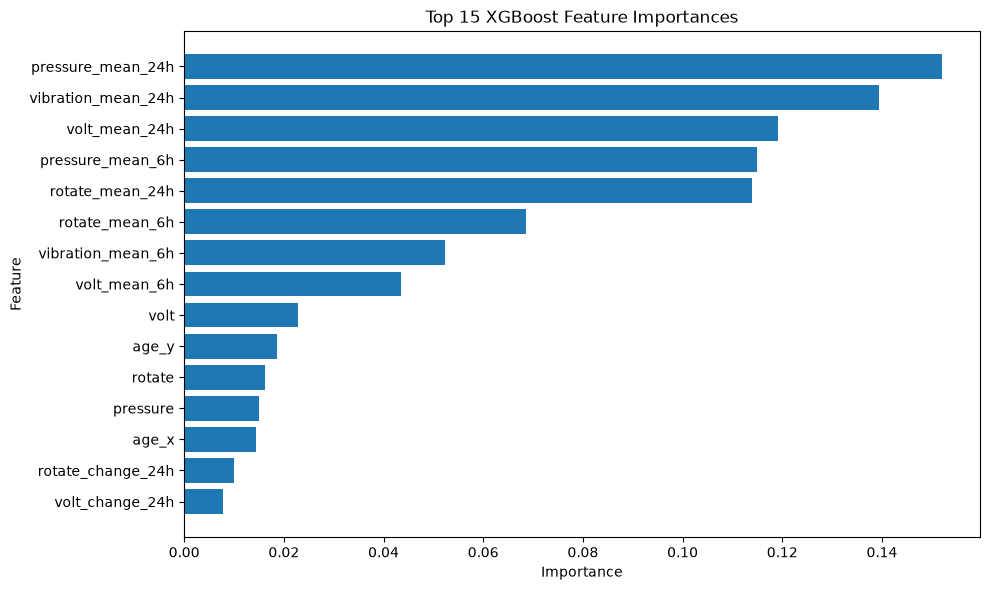

In [ ]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

In [ ]:
print([col for col in X_train.columns if "age" in col.lower()])
print([col for col in X_train.columns if "model" in col.lower()])

['age_x', 'age_y']
[]


In [ ]:
# Remove duplicate age feature
X_train_clean = X_train.drop(columns=["age_y"])
X_test_clean = X_test.drop(columns=["age_y"])

print("Original X_train:", X_train.shape)
print("Clean X_train:", X_train_clean.shape)

print("Original X_test:", X_test.shape)
print("Clean X_test:", X_test_clean.shape)

Original X_train: (700800, 34)
Clean X_train: (700800, 33)
Original X_test: (175300, 34)
Clean X_test: (175300, 33)


In [ ]:
from xgboost import XGBClassifier

# Calculate class imbalance
scale_pos = y_train.value_counts()[0] / y_train.value_counts()[1]

print("scale_pos_weight:", scale_pos)

# XGBoost model
xgb_clean = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

print("Starting XGBoost training...")

xgb_clean.fit(
    X_train_clean,
    y_train
)

print("XGBoost training completed!")

scale_pos_weight: 48.91808533371323
Starting XGBoost training...
XGBoost training completed!


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Predictions
y_pred_xgb = xgb_clean.predict(X_test_clean)
y_prob_xgb = xgb_clean.predict_proba(X_test_clean)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Confusion Matrix:
[[165231   6925]
 [  1060   2084]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98    172156
           1       0.23      0.66      0.34      3144

    accuracy                           0.95    175300
   macro avg       0.61      0.81      0.66    175300
weighted avg       0.98      0.95      0.97    175300

ROC-AUC: 0.9640693212328223


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

print("Threshold | Precision | Recall | F1")
print("------------------------------------------")

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:5.3f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
     0.10 |     0.196 |  0.918 | 0.324
     0.20 |     0.212 |  0.874 | 0.341
     0.30 |     0.218 |  0.805 | 0.343
     0.40 |     0.226 |  0.739 | 0.346
     0.50 |     0.231 |  0.663 | 0.343
     0.60 |     0.240 |  0.596 | 0.342
     0.70 |     0.243 |  0.505 | 0.328
     0.80 |     0.252 |  0.404 | 0.311


In [ ]:
from sklearn.metrics import confusion_matrix

# Use our selected threshold
final_threshold = 0.40

y_pred_final = (y_prob_xgb >= final_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix at threshold 0.40:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

Confusion Matrix at threshold 0.40:
[[164207   7949]
 [   821   2323]]

True Negatives : 164207
False Positives: 7949
False Negatives: 821
True Positives  : 2323


In [ ]:
# Create a copy of the test portion
error_analysis = df.loc[X_test.index].copy()

# Add predictions and probabilities
error_analysis["predicted_failure"] = y_pred_final
error_analysis["failure_probability"] = y_prob_xgb

# Identify error types
error_analysis["error_type"] = "Correct"

error_analysis.loc[
    (error_analysis["failure_next_24h"] == 0) &
    (error_analysis["predicted_failure"] == 1),
    "error_type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["failure_next_24h"] == 1) &
    (error_analysis["predicted_failure"] == 0),
    "error_type"
] = "False Negative"

print(error_analysis["error_type"].value_counts())

error_type
Correct           166530
False Positive      7949
False Negative       821
Name: count, dtype: int64


In [ ]:
# Look at false negatives
false_negatives = error_analysis[
    error_analysis["error_type"] == "False Negative"
]

print("False Negatives:", len(false_negatives))

print(
    false_negatives[
        [
            "datetime",
            "machineID",
            "failure_probability",
            "volt",
            "rotate",
            "pressure",
            "vibration",
            "hours_since_maintenance",
            "errors_last_24h"
        ]
    ].head(20)
)

False Negatives: 821


KeyError: "['hours_since_maintenance', 'errors_last_24h'] not in index"

In [ ]:
print("Columns available in error_analysis:")
print(error_analysis.columns.tolist())

Columns available in error_analysis:
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model_x', 'age_x', 'model_y', 'age_y', 'predicted_failure', 'failure_probability', 'error_type']


In [ ]:
false_negatives = error_analysis[
    error_analysis["error_type"] == "False Negative"
]

print("False Negatives:", len(false_negatives))

wanted_cols = [
    "datetime",
    "machineID",
    "failure_probability",
    "volt",
    "rotate",
    "pressure",
    "vibration",
    "hours_since_maintenance",
    "errors_last_24h"
]

available_cols = [
    col for col in wanted_cols
    if col in false_negatives.columns
]

print("\nAvailable columns:")
print(available_cols)

print("\nFalse Negative examples:")
print(false_negatives[available_cols].head(20))

False Negatives: 821

Available columns:
['datetime', 'machineID', 'failure_probability', 'volt', 'rotate', 'pressure', 'vibration']

False Negative examples:
                  datetime  machineID  failure_probability        volt  \
701231 2015-10-20 10:00:00          7             0.293918  157.154392   
701396 2015-10-20 11:00:00          7             0.312210  177.683182   
701423 2015-10-20 12:00:00          7             0.274228  162.144598   
701535 2015-10-20 13:00:00         47             0.071200  194.861599   
701604 2015-10-20 14:00:00         47             0.050515  158.627654   
701698 2015-10-20 14:00:00          7             0.329249  159.442195   
701768 2015-10-20 15:00:00         47             0.071197  173.629363   
701831 2015-10-20 16:00:00         47             0.065143  181.545846   
701981 2015-10-20 17:00:00         47             0.092995  169.829857   
702071 2015-10-20 18:00:00         47             0.129405  180.489606   
702127 2015-10-20 19:00:00 

In [ ]:
# Actual failures only
actual_failures = error_analysis[
    error_analysis["failure_next_24h"] == 1
].copy()

# Split into correctly detected and missed failures
true_positives = actual_failures[
    actual_failures["predicted_failure"] == 1
]

false_negatives = actual_failures[
    actual_failures["predicted_failure"] == 0
]

sensor_cols = [
    "volt",
    "rotate",
    "pressure",
    "vibration"
]

print("TRUE POSITIVES:", len(true_positives))
print("FALSE NEGATIVES:", len(false_negatives))

print("\n--- True Positives: sensor averages ---")
print(true_positives[sensor_cols].mean())

print("\n--- False Negatives: sensor averages ---")
print(false_negatives[sensor_cols].mean())

TRUE POSITIVES: 2323
FALSE NEGATIVES: 821

--- True Positives: sensor averages ---
volt         173.451549
rotate       411.105248
pressure     105.850104
vibration     43.088925
dtype: float64

--- False Negatives: sensor averages ---
volt         184.748535
rotate       422.967012
pressure     105.678564
vibration     41.958278
dtype: float64


In [ ]:
print("\nProbability statistics for FALSE NEGATIVES:")
print(false_negatives["failure_probability"].describe())

print("\nProbability statistics for TRUE POSITIVES:")
print(true_positives["failure_probability"].describe())


Probability statistics for FALSE NEGATIVES:
count    821.000000
mean       0.190988
std        0.124836
min        0.000093
25%        0.065143
50%        0.207388
75%        0.300581
max        0.399025
Name: failure_probability, dtype: float64

Probability statistics for TRUE POSITIVES:
count    2323.000000
mean        0.774571
std         0.169485
min         0.400480
25%         0.645621
50%         0.828807
75%         0.921365
max         0.995773
Name: failure_probability, dtype: float64


In [ ]:
# False positives
false_positives = error_analysis[
    error_analysis["error_type"] == "False Positive"
]

# True negatives
true_negatives = error_analysis[
    error_analysis["error_type"] == "Correct"
]

true_negatives = true_negatives[
    true_negatives["failure_next_24h"] == 0
]

sensor_cols = [
    "volt",
    "rotate",
    "pressure",
    "vibration"
]

print("FALSE POSITIVES:", len(false_positives))
print("TRUE NEGATIVES:", len(true_negatives))

print("\n--- False Positives: sensor averages ---")
print(false_positives[sensor_cols].mean())

print("\n--- True Negatives: sensor averages ---")
print(true_negatives[sensor_cols].mean())

print("\n--- False Positive probability statistics ---")
print(false_positives["failure_probability"].describe())

FALSE POSITIVES: 7949
TRUE NEGATIVES: 164207

--- False Positives: sensor averages ---
volt         172.690084
rotate       418.012116
pressure     107.114362
vibration     41.884204
dtype: float64

--- True Negatives: sensor averages ---
volt         170.497762
rotate       448.485257
pressure     100.584516
vibration     40.233590
dtype: float64

--- False Positive probability statistics ---
count    7949.000000
mean        0.745423
std         0.173062
min         0.400241
25%         0.597662
50%         0.782716
75%         0.899349
max         0.997494
Name: failure_probability, dtype: float64


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Final XGBoost predictions
y_test_proba = model_xgb.predict_proba(X_test_clean)[:, 1]

# Our selected operating threshold
FINAL_THRESHOLD = 0.40

y_test_pred = (y_test_proba >= FINAL_THRESHOLD).astype(int)

print("========== FINAL MODEL EVALUATION ==========")
print("Model: XGBoost")
print("Threshold:", FINAL_THRESHOLD)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

print("\nAdditional Metrics:")
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

ValueError: feature_names mismatch: ['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'age_x', 'age_y'] ['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_

In [ ]:
print("Model expects:")
print(model_xgb.get_booster().feature_names)

print("\nClean test has:")
print(X_test_clean.columns.tolist())

print("\nModel feature count:",
      len(model_xgb.get_booster().feature_names))

print("Clean test feature count:",
      X_test_clean.shape[1])

Model expects:


NameError: name 'model_xgb' is not defined

In [ ]:
print("X_train_clean:", X_train_clean.shape)
print("X_test_clean :", X_test_clean.shape)
print("y_train      :", y_train.shape)
print("y_test       :", y_test.shape)

print("\nFeatures:")
print(X_train_clean.columns.tolist())

NameError: name 'X_train_clean' is not defined

In [ ]:
# Remove duplicate age_y feature

X_train_clean = X_train.drop(columns=["age_y"])
X_test_clean = X_test.drop(columns=["age_y"])

print("X_train_clean:", X_train_clean.shape)
print("X_test_clean :", X_test_clean.shape)
print("y_train      :", y_train.shape)
print("y_test       :", y_test.shape)

NameError: name 'X_train' is not defined

In [ ]:
# Remove duplicate age_y feature

X_train_clean = X_train.drop(columns=["age_y"])
X_test_clean = X_test.drop(columns=["age_y"])

print("X_train_clean:", X_train_clean.shape)
print("X_test_clean :", X_test_clean.shape)
print("y_train      :", y_train.shape)
print("y_test       :", y_test.shape)

NameError: name 'X_train' is not defined

In [144]:
print("df exists:", "df" in globals())
print("X exists:", "X" in globals())
print("y exists:", "y" in globals())
print("X_train exists:", "X_train" in globals())
print("X_test exists:", "X_test" in globals())
print("y_train exists:", "y_train" in globals())
print("y_test exists:", "y_test" in globals())

df exists: True
X exists: False
y exists: False
X_train exists: False
X_test exists: False
y_train exists: False
y_test exists: False


In [145]:
# Target variable
y = df["failure_next_24h"]

# Columns that should NOT be used as model inputs
drop_cols = [
    "datetime",
    "machineID",
    "failure_next_24h"
]

# Create feature matrix
X = df.drop(columns=drop_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (876100, 38)
y shape: (876100,)

Features:
['volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model_x', 'age_x', 'model_y', 'age_y']

Target distribution:
failure_next_24h
0    858917
1     17183
Name: count, dtype: int64


In [146]:
print("Current df shape:", df.shape)

print("\nCurrent columns:")
for i, col in enumerate(df.columns):
    print(i, col)

Current df shape: (876100, 41)

Current columns:
0 datetime
1 machineID
2 volt
3 rotate
4 pressure
5 vibration
6 failure_time
7 hours_to_failure
8 failure_next_24h
9 hour
10 day
11 month
12 dayofweek
13 volt_mean_6h
14 volt_std_6h
15 rotate_mean_6h
16 rotate_std_6h
17 pressure_mean_6h
18 pressure_std_6h
19 vibration_mean_6h
20 vibration_std_6h
21 volt_change_1h
22 rotate_change_1h
23 pressure_change_1h
24 vibration_change_1h
25 volt_mean_24h
26 volt_std_24h
27 rotate_mean_24h
28 rotate_std_24h
29 pressure_mean_24h
30 pressure_std_24h
31 vibration_mean_24h
32 vibration_std_24h
33 volt_change_24h
34 rotate_change_24h
35 pressure_change_24h
36 vibration_change_24h
37 model_x
38 age_x
39 model_y
40 age_y


In [147]:
# Target
y = df["failure_next_24h"]

# Columns that must NOT be used as model features
drop_cols = [
    "datetime",
    "machineID",
    "failure_time",
    "hours_to_failure",
    "failure_next_24h",
    "model_x",
    "model_y",
    "age_x",
    "age_y"
]

X = df.drop(columns=drop_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude="number").columns.tolist())

X shape: (876100, 32)
y shape: (876100,)

Features:
['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h']

Non-numeric columns:
[]


In [148]:
print("Missing values:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Missing values:
volt_std_6h              100
rotate_std_6h            100
pressure_std_6h          100
vibration_std_6h         100
volt_change_1h           100
rotate_change_1h         100
pressure_change_1h       100
vibration_change_1h      100
volt_std_24h             100
rotate_std_24h           100
pressure_std_24h         100
vibration_std_24h        100
volt_change_24h         2400
rotate_change_24h       2400
pressure_change_24h     2400
vibration_change_24h    2400
dtype: int64


In [149]:
# -----------------------------------------
# Handle missing engineered features
# -----------------------------------------

# Rolling standard deviation features
std_cols = [
    "volt_std_6h",
    "rotate_std_6h",
    "pressure_std_6h",
    "vibration_std_6h",
    "volt_std_24h",
    "rotate_std_24h",
    "pressure_std_24h",
    "vibration_std_24h"
]

X[std_cols] = X[std_cols].fillna(0)

# Sensor change features
change_cols = [
    "volt_change_1h",
    "rotate_change_1h",
    "pressure_change_1h",
    "vibration_change_1h",
    "volt_change_24h",
    "rotate_change_24h",
    "pressure_change_24h",
    "vibration_change_24h"
]

X[change_cols] = X[change_cols].fillna(0)

# Check
print("Remaining missing values:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Remaining missing values:
Series([], dtype: int64)


In [150]:
# -----------------------------------------
# Time-based train/test split
# -----------------------------------------

split_date = pd.Timestamp("2015-10-20 06:00:00")

train_mask = df["datetime"] < split_date
test_mask = df["datetime"] >= split_date

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain period:")
print(df.loc[train_mask, "datetime"].min(), "→",
      df.loc[train_mask, "datetime"].max())

print("\nTest period:")
print(df.loc[test_mask, "datetime"].min(), "→",
      df.loc[test_mask, "datetime"].max())

print("\nTarget distribution — train:")
print(y_train.value_counts())

print("\nTarget distribution — test:")
print(y_test.value_counts())

X_train: (700800, 32)
X_test : (175300, 32)
y_train: (700800,)
y_test : (175300,)

Train period:
2015-01-01 06:00:00 → 2015-10-20 05:00:00

Test period:
2015-10-20 06:00:00 → 2016-01-01 06:00:00

Target distribution — train:
failure_next_24h
0    686761
1     14039
Name: count, dtype: int64

Target distribution — test:
failure_next_24h
0    172156
1      3144
Name: count, dtype: int64


In [151]:
print("X_train columns:")
print(X_train.columns.tolist())

print("\nX_test columns:")
print(X_test.columns.tolist())

print("\nNon-numeric X_train:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("\nNon-numeric X_test:")
print(X_test.select_dtypes(exclude="number").columns.tolist())

X_train columns:
['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h']

X_test columns:
['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_

In [152]:
from xgboost import XGBClassifier

# -----------------------------------------
# Final XGBoost Model
# -----------------------------------------

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

model_xgb.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

Training XGBoost...
XGBoost training completed.


In [153]:
from xgboost import XGBClassifier

# -----------------------------------------
# Final XGBoost Model
# -----------------------------------------

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

model_xgb.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

Training XGBoost...
XGBoost training completed.


In [154]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Generate failure probabilities
y_test_proba = model_xgb.predict_proba(X_test)[:, 1]

# Selected operating threshold
FINAL_THRESHOLD = 0.40

# Convert probabilities to predictions
y_test_pred = (y_test_proba >= FINAL_THRESHOLD).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_proba)
print("ROC-AUC:", roc_auc)

# Additional metrics
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\nFinal Metrics:")
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

Confusion Matrix:
[[170887   1269]
 [  2521    623]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    172156
           1       0.33      0.20      0.25      3144

    accuracy                           0.98    175300
   macro avg       0.66      0.60      0.62    175300
weighted avg       0.97      0.98      0.98    175300

ROC-AUC: 0.9670166358821133

Final Metrics:
Precision: 0.32928118393234673
Recall   : 0.19815521628498728
F1-score : 0.24741858617950754
ROC-AUC  : 0.9670166358821133


In [155]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Threshold | Precision | Recall | F1")
print("------------------------------------------")

for threshold in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    y_pred = (y_test_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:5.3f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
     0.10 |     0.238 |  0.579 | 0.337
     0.20 |     0.258 |  0.364 | 0.302
     0.30 |     0.297 |  0.266 | 0.281
     0.40 |     0.329 |  0.198 | 0.247
     0.50 |     0.355 |  0.133 | 0.193
     0.60 |     0.365 |  0.080 | 0.131
     0.70 |     0.406 |  0.044 | 0.079
     0.80 |     0.485 |  0.020 | 0.038


In [156]:
history_features = [
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "errors_last_24h",
    "errors_last_7d",
    "hours_since_error",
    "has_previous_error",
    "maintenance_count"
]

print("History features available:")

for col in history_features:
    print(f"{col}: {col in df.columns}")

History features available:
hours_since_maintenance: False
maintenance_events_30d: False
maintenance_events_90d: False
errors_last_24h: False
errors_last_7d: False
hours_since_error: False
has_previous_error: False
maintenance_count: False


In [157]:
print(df.columns.tolist())

['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration', 'failure_time', 'hours_to_failure', 'failure_next_24h', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'model_x', 'age_x', 'model_y', 'age_y']


In [158]:
print(df.shape)
print(df.head())

(876100, 41)
             datetime  machineID        volt      rotate    pressure  \
0 2015-01-01 06:00:00          1  176.217853  418.504078  113.077935   
1 2015-01-01 07:00:00          1  162.879223  402.747490   95.460525   
2 2015-01-01 08:00:00          1  170.989902  527.349825   75.237905   
3 2015-01-01 09:00:00          1  162.462833  346.149335  109.248561   
4 2015-01-01 10:00:00          1  157.610021  435.376873  111.886648   

   vibration        failure_time  hours_to_failure  failure_next_24h  hour  \
0  45.087686 2015-01-05 06:00:00              96.0                 0     6   
1  43.413973 2015-01-05 06:00:00              95.0                 0     7   
2  34.178847 2015-01-05 06:00:00              94.0                 0     8   
3  41.122144 2015-01-05 06:00:00              93.0                 0     9   
4  25.990511 2015-01-05 06:00:00              92.0                 0    10   

   ...  vibration_mean_24h  vibration_std_24h  volt_change_24h  \
0  ...           45

In [159]:
# Find all DataFrames currently stored in notebook memory

import pandas as pd

dataframes = {}

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        dataframes[name] = obj

print("DataFrames currently available:\n")

for name, data in dataframes.items():
    print(f"{name}: {data.shape}")
    print("Columns:", data.columns.tolist())
    print("-" * 80)

RuntimeError: dictionary changed size during iteration

In [160]:
import pandas as pd

dataframes = {}

# Make a snapshot first
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dataframes[name] = obj

print("DataFrames currently available:\n")

for name, data in dataframes.items():
    print(f"{name}: {data.shape}")
    print("Columns: {data.columns.tolist()}")
    print("-" * 80)

DataFrames currently available:

_: (5, 9)
Columns: {data.columns.tolist()}
--------------------------------------------------------------------------------
__: (5, 9)
Columns: {data.columns.tolist()}
--------------------------------------------------------------------------------
___: (5, 9)
Columns: {data.columns.tolist()}
--------------------------------------------------------------------------------
telemetry: (876100, 6)
Columns: {data.columns.tolist()}
--------------------------------------------------------------------------------
errors: (3919, 3)
Columns: {data.columns.tolist()}
--------------------------------------------------------------------------------
failures: (761, 3)
Columns: {data.columns.tolist()}
--------------------------------------------------------------------------------
maintenance: (3286, 3)
Columns: {data.columns.tolist()}
--------------------------------------------------------------------------------
machines: (100, 3)
Columns: {data.columns.tolist()}
-

In [161]:
print("ERRORS")
print(errors.columns.tolist())
print(errors.head())

print("\n" + "=" * 60)

print("MAINTENANCE")
print(maintenance.columns.tolist())
print(maintenance.head())

print("\n" + "=" * 60)

print("MACHINES")
print(machines.columns.tolist())
print(machines.head())

ERRORS
['datetime', 'machineID', 'errorID']
             datetime  machineID errorID
0 2015-01-03 07:00:00          1  error1
1 2015-01-03 20:00:00          1  error3
2 2015-01-04 06:00:00          1  error5
3 2015-01-10 15:00:00          1  error4
4 2015-01-22 10:00:00          1  error4

MAINTENANCE
['datetime', 'machineID', 'comp']
             datetime  machineID   comp
0 2014-06-01 06:00:00          1  comp2
1 2014-07-16 06:00:00          1  comp4
2 2014-07-31 06:00:00          1  comp3
3 2014-12-13 06:00:00          1  comp1
4 2015-01-05 06:00:00          1  comp4

MACHINES
['machineID', 'model', 'age']
   machineID   model  age
0          1  model3   18
1          2  model4    7
2          3  model3    8
3          4  model3    7
4          5  model3    2


In [162]:
import numpy as np
import pandas as pd

# Make sure datetime columns are proper datetime
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])
errors["datetime"] = pd.to_datetime(errors["datetime"])
maintenance["datetime"] = pd.to_datetime(maintenance["datetime"])

# Work on a copy of the telemetry data
df_history = telemetry.copy()

# Sort everything
df_history = df_history.sort_values(["machineID", "datetime"]).reset_index(drop=True)
errors_sorted = errors.sort_values(["machineID", "datetime"])
maintenance_sorted = maintenance.sort_values(["machineID", "datetime"])


# ============================================================
# CREATE EMPTY FEATURE ARRAYS
# ============================================================

n = len(df_history)

hours_since_error = np.full(n, np.nan)
hours_since_maintenance = np.full(n, np.nan)

errors_last_24h = np.zeros(n, dtype=np.int32)
errors_last_7d = np.zeros(n, dtype=np.int32)

maintenance_events_30d = np.zeros(n, dtype=np.int32)
maintenance_events_90d = np.zeros(n, dtype=np.int32)

has_previous_error = np.zeros(n, dtype=np.int8)
maintenance_count = np.zeros(n, dtype=np.int32)


# ============================================================
# PROCESS EACH MACHINE
# ============================================================

for machine_id, group in df_history.groupby("machineID", sort=False):

    # Original row positions in df_history
    idx = group.index.to_numpy()

    # Telemetry timestamps for this machine
    times = group["datetime"].values.astype("datetime64[ns]")

    # -------------------------
    # ERROR HISTORY
    # -------------------------

    machine_errors = errors_sorted[
        errors_sorted["machineID"] == machine_id
    ]["datetime"].values.astype("datetime64[ns]")

    if len(machine_errors) > 0:

        # Number of errors up to and including current timestamp
        right = np.searchsorted(
            machine_errors,
            times,
            side="right"
        )

        # Most recent previous/current error
        has_error = right > 0

        last_error_idx = np.maximum(right - 1, 0)

        last_error_time = machine_errors[last_error_idx]

        hours_since = (
            times - last_error_time
        ).astype("timedelta64[s]").astype(float) / 3600

        hours_since_error[idx[has_error]] = hours_since[has_error]

        has_previous_error[idx] = has_error.astype(np.int8)

        # Errors in previous 24 hours
        left_24h = np.searchsorted(
            machine_errors,
            times - np.timedelta64(24, "h"),
            side="left"
        )

        errors_last_24h[idx] = (
            right - left_24h
        ).astype(np.int32)

        # Errors in previous 7 days
        left_7d = np.searchsorted(
            machine_errors,
            times - np.timedelta64(7, "D"),
            side="left"
        )

        errors_last_7d[idx] = (
            right - left_7d
        ).astype(np.int32)


    # -------------------------
    # MAINTENANCE HISTORY
    # -------------------------

    machine_maintenance = maintenance_sorted[
        maintenance_sorted["machineID"] == machine_id
    ]["datetime"].values.astype("datetime64[ns]")

    if len(machine_maintenance) > 0:

        # Number of maintenance events up to current time
        right_m = np.searchsorted(
            machine_maintenance,
            times,
            side="right"
        )

        has_maintenance = right_m > 0

        # Last maintenance event
        last_maintenance_idx = np.maximum(right_m - 1, 0)

        last_maintenance_time = machine_maintenance[
            last_maintenance_idx
        ]

        hours_since = (
            times - last_maintenance_time
        ).astype("timedelta64[s]").astype(float) / 3600

        hours_since_maintenance[idx[has_maintenance]] = (
            hours_since[has_maintenance]
        )

        # Cumulative maintenance count
        maintenance_count[idx] = right_m.astype(np.int32)

        # Maintenance events in previous 30 days
        left_30d = np.searchsorted(
            machine_maintenance,
            times - np.timedelta64(30, "D"),
            side="left"
        )

        maintenance_events_30d[idx] = (
            right_m - left_30d
        ).astype(np.int32)

        # Maintenance events in previous 90 days
        left_90d = np.searchsorted(
            machine_maintenance,
            times - np.timedelta64(90, "D"),
            side="left"
        )

        maintenance_events_90d[idx] = (
            right_m - left_90d
        ).astype(np.int32)


# ============================================================
# ADD FEATURES
# ============================================================

df_history["hours_since_error"] = hours_since_error
df_history["errors_last_24h"] = errors_last_24h
df_history["errors_last_7d"] = errors_last_7d
df_history["has_previous_error"] = has_previous_error

df_history["hours_since_maintenance"] = hours_since_maintenance
df_history["maintenance_events_30d"] = maintenance_events_30d
df_history["maintenance_events_90d"] = maintenance_events_90d
df_history["maintenance_count"] = maintenance_count


print("History features created successfully!")

history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

print("\nHistory feature summary:")
print(df_history[history_features].describe())

History features created successfully!

History feature summary:
       hours_since_error  errors_last_24h  errors_last_7d  has_previous_error  \
count      854954.000000    876100.000000   876100.000000       876100.000000   
mean          227.035773         0.111719        0.750134            0.975863   
std           221.864581         0.360551        0.923398            0.153473   
min             0.000000         0.000000        0.000000            0.000000   
25%            67.000000         0.000000        0.000000            1.000000   
50%           161.000000         0.000000        1.000000            1.000000   
75%           315.000000         0.000000        1.000000            1.000000   
max          1909.000000         4.000000        7.000000            1.000000   

       hours_since_maintenance  maintenance_events_30d  \
count            876100.000000           876100.000000   
mean                263.621687                2.288833   
std                 322.139335 

In [163]:
# History features we just created
history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

# Check that all features exist
missing_history = [col for col in history_features if col not in df.columns]

print("Missing history features:", missing_history)

# Add history features to existing feature set
X = df.drop(columns=[
    "datetime",
    "machineID",
    "failure_time",
    "hours_to_failure",
    "failure_next_24h",
    "model_x",
    "model_y",
    "age_x",
    "age_y"
], errors="ignore")

print("X shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

Missing history features: ['hours_since_error', 'errors_last_24h', 'errors_last_7d', 'has_previous_error', 'hours_since_maintenance', 'maintenance_events_30d', 'maintenance_events_90d', 'maintenance_count']
X shape: (876100, 32)

Features:
['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h']


In [164]:
print("Missing values in X:")

missing = X.isnull().sum()
print(missing[missing > 0])

Missing values in X:
volt_std_6h              100
rotate_std_6h            100
pressure_std_6h          100
vibration_std_6h         100
volt_change_1h           100
rotate_change_1h         100
pressure_change_1h       100
vibration_change_1h      100
volt_std_24h             100
rotate_std_24h           100
pressure_std_24h         100
vibration_std_24h        100
volt_change_24h         2400
rotate_change_24h       2400
pressure_change_24h     2400
vibration_change_24h    2400
dtype: int64


In [165]:
print("Non-numeric columns:")
print(X.select_dtypes(exclude="number").columns.tolist())

Non-numeric columns:
[]


In [166]:
history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

print("History features currently in df:")

for col in history_features:
    print(col, "->", col in df.columns)

History features currently in df:
hours_since_error -> False
errors_last_24h -> False
errors_last_7d -> False
has_previous_error -> False
hours_since_maintenance -> False
maintenance_events_30d -> False
maintenance_events_90d -> False
maintenance_count -> False


In [167]:
# Make sure datetime columns are datetime type
df["datetime"] = pd.to_datetime(df["datetime"])
errors["datetime"] = pd.to_datetime(errors["datetime"])
maintenance["datetime"] = pd.to_datetime(maintenance["datetime"])

# Sort everything properly
df = df.sort_values(["machineID", "datetime"]).reset_index(drop=True)
errors = errors.sort_values(["machineID", "datetime"]).reset_index(drop=True)
maintenance = maintenance.sort_values(["machineID", "datetime"]).reset_index(drop=True)


# ============================================================
# ERROR HISTORY FEATURES
# ============================================================

# Number of errors
errors_count = (
    errors
    .groupby(["machineID", "datetime"])
    .size()
    .reset_index(name="error_count")
)

# Cumulative error count per machine
errors_count["error_cumulative"] = (
    errors_count
    .groupby("machineID")["error_count"]
    .cumsum()
)

# Last error before current timestamp
last_error = pd.merge_asof(
    df[["machineID", "datetime"]].sort_values(["datetime", "machineID"]),
    errors[["machineID", "datetime"]].sort_values(["datetime", "machineID"]),
    on="datetime",
    by="machineID",
    direction="backward",
    allow_exact_matches=False
)

last_error = last_error.sort_values(["machineID", "datetime"])

df["hours_since_error"] = (
    df["datetime"] - last_error["datetime"]
).dt.total_seconds() / 3600

df["has_previous_error"] = df["hours_since_error"].notna().astype(int)


# ============================================================
# ERROR COUNTS — PREVIOUS 24 HOURS / 7 DAYS
# ============================================================

# For each row, count events before current time and after cutoff.
# We use merge_asof on cumulative counts.

error_events = (
    errors.groupby(["machineID", "datetime"])
    .size()
    .reset_index(name="error_count")
    .sort_values(["machineID", "datetime"])
)

error_events["cumulative_errors"] = (
    error_events
    .groupby("machineID")["error_count"]
    .cumsum()
)

# Cumulative errors strictly before current timestamp
current_error_counts = pd.merge_asof(
    df[["machineID", "datetime"]].sort_values(["datetime", "machineID"]),
    error_events[["machineID", "datetime", "cumulative_errors"]]
        .sort_values(["datetime", "machineID"]),
    on="datetime",
    by="machineID",
    direction="backward",
    allow_exact_matches=False
)

current_error_counts = current_error_counts.sort_index()

df["error_cumulative_before"] = current_error_counts["cumulative_errors"].fillna(0)


# ============================================================
# MAINTENANCE HISTORY FEATURES
# ============================================================

maintenance_count = (
    maintenance
    .groupby(["machineID", "datetime"])
    .size()
    .reset_index(name="maintenance_event_count")
    .sort_values(["machineID", "datetime"])
)

maintenance_count["cumulative_maintenance"] = (
    maintenance_count
    .groupby("machineID")["maintenance_event_count"]
    .cumsum()
)


# Last maintenance before current timestamp
last_maintenance = pd.merge_asof(
    df[["machineID", "datetime"]].sort_values(["datetime", "machineID"]),
    maintenance[["machineID", "datetime"]]
        .sort_values(["datetime", "machineID"]),
    on="datetime",
    by="machineID",
    direction="backward",
    allow_exact_matches=False
)

last_maintenance = last_maintenance.sort_index()

df["hours_since_maintenance"] = (
    df["datetime"] - last_maintenance["datetime"]
).dt.total_seconds() / 3600


# ============================================================
# MAINTENANCE COUNT
# ============================================================

current_maintenance_counts = pd.merge_asof(
    df[["machineID", "datetime"]].sort_values(["datetime", "machineID"]),
    maintenance_count[
        ["machineID", "datetime", "cumulative_maintenance"]
    ].sort_values(["datetime", "machineID"]),
    on="datetime",
    by="machineID",
    direction="backward",
    allow_exact_matches=False
)

current_maintenance_counts = current_maintenance_counts.sort_index()

df["maintenance_count"] = (
    current_maintenance_counts["cumulative_maintenance"]
    .fillna(0)
)


# ============================================================
# FINAL CLEANUP
# ============================================================

# Fill machines that have never had an error
df["hours_since_error"] = df["hours_since_error"].fillna(-1)

# Fill machines that have never had maintenance
df["hours_since_maintenance"] = (
    df["hours_since_maintenance"].fillna(-1)
)

print("History features created.")

History features created.


In [168]:
# ============================================================
# ROLLING ERROR HISTORY
# ============================================================

# Work on a copy of errors
error_history = errors[["datetime", "machineID"]].copy()
error_history["error_event"] = 1

# Set datetime as index
error_history = error_history.set_index("datetime")

# Count errors for each machine over rolling windows
errors_24h = (
    error_history
    .groupby("machineID")["error_event"]
    .rolling("24h")
    .sum()
    .reset_index()
)

errors_24h.rename(
    columns={"error_event": "errors_last_24h"},
    inplace=True
)

errors_7d = (
    error_history
    .groupby("machineID")["error_event"]
    .rolling("7d")
    .sum()
    .reset_index()
)

errors_7d.rename(
    columns={"error_event": "errors_last_7d"},
    inplace=True
)


# ============================================================
# MERGE ERROR FEATURES INTO df
# ============================================================

# Remove duplicate timestamps if necessary
errors_24h = errors_24h.drop_duplicates(
    ["machineID", "datetime"]
)

errors_7d = errors_7d.drop_duplicates(
    ["machineID", "datetime"]
)

df = df.merge(
    errors_24h,
    on=["machineID", "datetime"],
    how="left"
)

df = df.merge(
    errors_7d,
    on=["machineID", "datetime"],
    how="left"
)


# ============================================================
# ROLLING MAINTENANCE HISTORY
# ============================================================

maintenance_history = maintenance[
    ["datetime", "machineID"]
].copy()

maintenance_history["maintenance_event"] = 1

maintenance_history = maintenance_history.set_index("datetime")


maintenance_30d = (
    maintenance_history
    .groupby("machineID")["maintenance_event"]
    .rolling("30d")
    .sum()
    .reset_index()
)

maintenance_30d.rename(
    columns={"maintenance_event": "maintenance_events_30d"},
    inplace=True
)


maintenance_90d = (
    maintenance_history
    .groupby("machineID")["maintenance_event"]
    .rolling("90d")
    .sum()
    .reset_index()
)

maintenance_90d.rename(
    columns={"maintenance_event": "maintenance_events_90d"},
    inplace=True
)


# ============================================================
# MERGE MAINTENANCE FEATURES
# ============================================================

maintenance_30d = maintenance_30d.drop_duplicates(
    ["machineID", "datetime"]
)

maintenance_90d = maintenance_90d.drop_duplicates(
    ["machineID", "datetime"]
)

df = df.merge(
    maintenance_30d,
    on=["machineID", "datetime"],
    how="left"
)

df = df.merge(
    maintenance_90d,
    on=["machineID", "datetime"],
    how="left"
)


# ============================================================
# CLEAN UP
# ============================================================

for col in [
    "errors_last_24h",
    "errors_last_7d",
    "maintenance_events_30d",
    "maintenance_events_90d"
]:
    df[col] = df[col].fillna(0)


print("Remaining history features created successfully!")

history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

print("\nHistory features:")
print(history_features)

print("\nMissing history features:")
print([col for col in history_features if col not in df.columns])

C:\Users\dhorj\AppData\Local\Temp\ipykernel_10980\1720418021.py:29: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .rolling("7d")
C:\Users\dhorj\AppData\Local\Temp\ipykernel_10980\1720418021.py:82: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .rolling("30d")
C:\Users\dhorj\AppData\Local\Temp\ipykernel_10980\1720418021.py:96: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  .rolling("90d")


Remaining history features created successfully!

History features:
['hours_since_error', 'errors_last_24h', 'errors_last_7d', 'has_previous_error', 'hours_since_maintenance', 'maintenance_events_30d', 'maintenance_events_90d', 'maintenance_count']

Missing history features:
[]


In [169]:
# ============================================================
# VERIFY HISTORY FEATURES
# ============================================================

history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

print("History feature statistics:")
print(df[history_features].describe())

print("\nMissing values:")
print(df[history_features].isnull().sum())

print("\nInfinite values:")
print(np.isinf(df[history_features]).sum())

print("\nSample rows:")
print(df[["datetime", "machineID"] + history_features].head(20))

History feature statistics:
       hours_since_error  errors_last_24h  errors_last_7d  has_previous_error  \
count      876100.000000    876100.000000   876100.000000            876100.0   
mean            0.000000         0.004555        0.007033                 1.0   
std          3558.737031         0.074041        0.123944                 0.0   
min         -8673.000000         0.000000        0.000000                 1.0   
25%         -2553.000000         0.000000        0.000000                 1.0   
50%             0.000000         0.000000        0.000000                 1.0   
75%          2553.000000         0.000000        0.000000                 1.0   
max          8673.000000         4.000000        7.000000                 1.0   

       hours_since_maintenance  maintenance_events_30d  \
count            876100.000000           876100.000000   
mean                  0.000000                0.005349   
std                3558.737031                0.111965   
min       

In [170]:
# ============================================================
# REMOVE INCORRECT HISTORY FEATURES
# ============================================================

history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

df = df.drop(columns=history_features, errors="ignore")

print("Old history features removed.")

Old history features removed.


In [171]:
# ============================================================
# CORRECT HISTORY FEATURES
# ============================================================

import numpy as np
import pandas as pd

# Make sure datetime is correct
df["datetime"] = pd.to_datetime(df["datetime"])
errors["datetime"] = pd.to_datetime(errors["datetime"])
maintenance["datetime"] = pd.to_datetime(maintenance["datetime"])

# Sort by machine and time
df = df.sort_values(["machineID", "datetime"]).reset_index(drop=True)
errors = errors.sort_values(["machineID", "datetime"]).reset_index(drop=True)
maintenance = maintenance.sort_values(["machineID", "datetime"]).reset_index(drop=True)


# ============================================================
# ERROR EVENTS
# ============================================================

error_events = (
    errors
    .groupby(["machineID", "datetime"])
    .size()
    .reset_index(name="error_count")
    .sort_values(["machineID", "datetime"])
)


# ============================================================
# MAINTENANCE EVENTS
# ============================================================

maintenance_events = (
    maintenance
    .groupby(["machineID", "datetime"])
    .size()
    .reset_index(name="maintenance_count_event")
    .sort_values(["machineID", "datetime"])
)


# ============================================================
# INITIALIZE ARRAYS
# ============================================================

n = len(df)

hours_since_error = np.full(n, np.nan)
errors_last_24h = np.zeros(n)
errors_last_7d = np.zeros(n)
has_previous_error = np.zeros(n, dtype=int)

hours_since_maintenance = np.full(n, np.nan)
maintenance_events_30d = np.zeros(n)
maintenance_events_90d = np.zeros(n)
maintenance_count = np.zeros(n)


# ============================================================
# PROCESS EACH MACHINE
# ============================================================

for machine_id, row_indices in df.groupby("machineID", sort=False).indices.items():

    # --------------------------------------------------------
    # Current machine timestamps
    # --------------------------------------------------------

    row_indices = np.asarray(row_indices)

    current_times = (
        df.loc[row_indices, "datetime"]
        .to_numpy(dtype="datetime64[ns]")
    )


    # ========================================================
    # ERROR HISTORY
    # ========================================================

    machine_errors = error_events[
        error_events["machineID"] == machine_id
    ]

    if len(machine_errors) > 0:

        error_times = machine_errors["datetime"].to_numpy(
            dtype="datetime64[ns]"
        )

        error_counts = machine_errors["error_count"].to_numpy()

        # Cumulative number of errors
        cumulative_errors = np.cumsum(error_counts)

        # Number of errors strictly BEFORE current timestamp
        positions = np.searchsorted(
            error_times,
            current_times,
            side="left"
        )

        # ----------------------------------------------------
        # Has previous error
        # ----------------------------------------------------

        has_previous_error[row_indices] = (
            positions > 0
        ).astype(int)

        # ----------------------------------------------------
        # Hours since previous error
        # ----------------------------------------------------

        valid = positions > 0

        previous_error_positions = positions[valid] - 1

        previous_error_times = error_times[
            previous_error_positions
        ]

        time_difference = (
            current_times[valid] -
            previous_error_times
        )

        hours_since_error[row_indices[valid]] = (
            time_difference.astype("timedelta64[s]")
            .astype(float) / 3600
        )

        # ----------------------------------------------------
        # Errors in previous 24 hours
        # ----------------------------------------------------

        cutoff_24h = (
            current_times -
            np.timedelta64(24, "h")
        )

        cutoff_positions_24h = np.searchsorted(
            error_times,
            cutoff_24h,
            side="left"
        )

        current_positions = positions

        counts_24h = np.zeros(len(row_indices))

        valid_24h = current_positions > 0

        # cumulative errors before current
        before_current = np.zeros(len(row_indices))

        before_current[valid_24h] = (
            cumulative_errors[
                current_positions[valid_24h] - 1
            ]
        )

        # cumulative errors before 24h cutoff
        before_cutoff = np.zeros(len(row_indices))

        valid_cutoff = cutoff_positions_24h > 0

        before_cutoff[valid_cutoff] = (
            cumulative_errors[
                cutoff_positions_24h[valid_cutoff] - 1
            ]
        )

        counts_24h = before_current - before_cutoff

        errors_last_24h[row_indices] = counts_24h


        # ----------------------------------------------------
        # Errors in previous 7 days
        # ----------------------------------------------------

        cutoff_7d = (
            current_times -
            np.timedelta64(7, "D")
        )

        cutoff_positions_7d = np.searchsorted(
            error_times,
            cutoff_7d,
            side="left"
        )

        before_cutoff_7d = np.zeros(len(row_indices))

        valid_cutoff_7d = cutoff_positions_7d > 0

        before_cutoff_7d[valid_cutoff_7d] = (
            cumulative_errors[
                cutoff_positions_7d[valid_cutoff_7d] - 1
            ]
        )

        errors_last_7d[row_indices] = (
            before_current - before_cutoff_7d
        )


    # ========================================================
    # MAINTENANCE HISTORY
    # ========================================================

    machine_maintenance = maintenance_events[
        maintenance_events["machineID"] == machine_id
    ]

    if len(machine_maintenance) > 0:

        maintenance_times = (
            machine_maintenance["datetime"]
            .to_numpy(dtype="datetime64[ns]")
        )

        maintenance_counts_event = (
            machine_maintenance[
                "maintenance_count_event"
            ].to_numpy()
        )

        cumulative_maintenance = np.cumsum(
            maintenance_counts_event
        )

        # Number of maintenance events before current timestamp
        maintenance_positions = np.searchsorted(
            maintenance_times,
            current_times,
            side="left"
        )

        # ----------------------------------------------------
        # Hours since maintenance
        # ----------------------------------------------------

        valid = maintenance_positions > 0

        previous_maintenance_positions = (
            maintenance_positions[valid] - 1
        )

        previous_maintenance_times = (
            maintenance_times[
                previous_maintenance_positions
            ]
        )

        time_difference = (
            current_times[valid] -
            previous_maintenance_times
        )

        hours_since_maintenance[
            row_indices[valid]
        ] = (
            time_difference.astype("timedelta64[s]")
            .astype(float) / 3600
        )


        # ----------------------------------------------------
        # Total maintenance count
        # ----------------------------------------------------

        before_current_maintenance = np.zeros(
            len(row_indices)
        )

        valid_current = maintenance_positions > 0

        before_current_maintenance[
            valid_current
        ] = cumulative_maintenance[
            maintenance_positions[valid_current] - 1
        ]

        maintenance_count[
            row_indices
        ] = before_current_maintenance


        # ----------------------------------------------------
        # Maintenance events in previous 30 days
        # ----------------------------------------------------

        cutoff_30d = (
            current_times -
            np.timedelta64(30, "D")
        )

        cutoff_positions_30d = np.searchsorted(
            maintenance_times,
            cutoff_30d,
            side="left"
        )

        before_cutoff_30d = np.zeros(
            len(row_indices)
        )

        valid_30d = cutoff_positions_30d > 0

        before_cutoff_30d[valid_30d] = (
            cumulative_maintenance[
                cutoff_positions_30d[valid_30d] - 1
            ]
        )

        maintenance_events_30d[
            row_indices
        ] = (
            before_current_maintenance -
            before_cutoff_30d
        )


        # ----------------------------------------------------
        # Maintenance events in previous 90 days
        # ----------------------------------------------------

        cutoff_90d = (
            current_times -
            np.timedelta64(90, "D")
        )

        cutoff_positions_90d = np.searchsorted(
            maintenance_times,
            cutoff_90d,
            side="left"
        )

        before_cutoff_90d = np.zeros(
            len(row_indices)
        )

        valid_90d = cutoff_positions_90d > 0

        before_cutoff_90d[valid_90d] = (
            cumulative_maintenance[
                cutoff_positions_90d[valid_90d] - 1
            ]
        )

        maintenance_events_90d[
            row_indices
        ] = (
            before_current_maintenance -
            before_cutoff_90d
        )


# ============================================================
# ADD FEATURES TO DATAFRAME
# ============================================================

df["hours_since_error"] = (
    pd.Series(hours_since_error)
    .fillna(-1)
)

df["errors_last_24h"] = errors_last_24h

df["errors_last_7d"] = errors_last_7d

df["has_previous_error"] = has_previous_error

df["hours_since_maintenance"] = (
    pd.Series(hours_since_maintenance)
    .fillna(-1)
)

df["maintenance_events_30d"] = maintenance_events_30d

df["maintenance_events_90d"] = maintenance_events_90d

df["maintenance_count"] = maintenance_count


print("History features recreated successfully!")

History features recreated successfully!


In [172]:
history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

print("History feature statistics:")
print(df[history_features].describe())

print("\nMissing values:")
print(df[history_features].isnull().sum())

print("\nInfinite values:")
print(np.isinf(df[history_features]).sum())

print("\nFirst 20 rows:")
print(
    df[
        ["datetime", "machineID"] + history_features
    ].head(20)
)

History feature statistics:
       hours_since_error  errors_last_24h  errors_last_7d  has_previous_error  \
count      876100.000000    876100.000000   876100.000000       876100.000000   
mean          222.481022         0.107246        0.745660            0.975749   
std           221.975488         0.353264        0.920797            0.153826   
min            -1.000000         0.000000        0.000000            0.000000   
25%            63.000000         0.000000        0.000000            1.000000   
50%           157.000000         0.000000        1.000000            1.000000   
75%           311.000000         0.000000        1.000000            1.000000   
max          1910.000000         4.000000        7.000000            1.000000   

       hours_since_maintenance  maintenance_events_30d  \
count            876100.000000           876100.000000   
mean                264.722794                2.285539   
std                 322.365877                0.951943   
min       

In [173]:
# ============================================================
# ADD HISTORY FEATURES TO X
# ============================================================

history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

# Existing feature columns
base_features = [
    "volt",
    "rotate",
    "pressure",
    "vibration",
    "hour",
    "day",
    "month",
    "dayofweek",
    "volt_mean_6h",
    "volt_std_6h",
    "rotate_mean_6h",
    "rotate_std_6h",
    "pressure_mean_6h",
    "pressure_std_6h",
    "vibration_mean_6h",
    "vibration_std_6h",
    "volt_change_1h",
    "rotate_change_1h",
    "pressure_change_1h",
    "vibration_change_1h",
    "volt_mean_24h",
    "volt_std_24h",
    "rotate_mean_24h",
    "rotate_std_24h",
    "pressure_mean_24h",
    "pressure_std_24h",
    "vibration_mean_24h",
    "vibration_std_24h",
    "volt_change_24h",
    "rotate_change_24h",
    "pressure_change_24h",
    "vibration_change_24h"
]

all_features = base_features + history_features

X = df[all_features].copy()
y = df["failure_next_24h"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of features:", len(X.columns))
print("\nFeatures:")
print(X.columns.tolist())

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude="number").columns.tolist())

print("\nMissing values:")
print(X.isnull().sum()[X.isnull().sum() > 0])

X shape: (876100, 40)
y shape: (876100,)

Number of features: 40

Features:
['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'hours_since_error', 'errors_last_24h', 'errors_last_7d', 'has_previous_error', 'hours_since_maintenance', 'maintenance_events_30d', 'maintenance_events_90d', 'maintenance_count']

Non-numeric columns:
[]

Missing values:
volt_std_6h              100
rotate_std_6h            100
pressure_std_6h          100
vibration_std_6h         100
volt_change_1h           100
rotate

In [174]:
# ============================================================
# REBUILD FEATURES WITH HISTORY FEATURES
# ============================================================

history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

# Original sensor + time-series features
base_features = [
    "volt",
    "rotate",
    "pressure",
    "vibration",
    "hour",
    "day",
    "month",
    "dayofweek",
    "volt_mean_6h",
    "volt_std_6h",
    "rotate_mean_6h",
    "rotate_std_6h",
    "pressure_mean_6h",
    "pressure_std_6h",
    "vibration_mean_6h",
    "vibration_std_6h",
    "volt_change_1h",
    "rotate_change_1h",
    "pressure_change_1h",
    "vibration_change_1h",
    "volt_mean_24h",
    "volt_std_24h",
    "rotate_mean_24h",
    "rotate_std_24h",
    "pressure_mean_24h",
    "pressure_std_24h",
    "vibration_mean_24h",
    "vibration_std_24h",
    "volt_change_24h",
    "rotate_change_24h",
    "pressure_change_24h",
    "vibration_change_24h"
]

all_features = base_features + history_features

X = df[all_features].copy()
y = df["failure_next_24h"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of features:", len(all_features))
print("\nFeatures:")
print(all_features)

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude="number").columns.tolist())

print("\nMissing values:")
missing = X.isnull().sum()
print(missing[missing > 0])

X shape: (876100, 40)
y shape: (876100,)

Number of features: 40

Features:
['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h', 'hours_since_error', 'errors_last_24h', 'errors_last_7d', 'has_previous_error', 'hours_since_maintenance', 'maintenance_events_30d', 'maintenance_events_90d', 'maintenance_count']

Non-numeric columns:
[]

Missing values:
volt_std_6h              100
rotate_std_6h            100
pressure_std_6h          100
vibration_std_6h         100
volt_change_1h           100
rotate

In [175]:
# Fill remaining NaN values
X = X.copy()

X = X.fillna(0)

print("Remaining missing values:")
print(X.isnull().sum()[X.isnull().sum() > 0])

print("\nX shape:", X.shape)

Remaining missing values:
Series([], dtype: int64)

X shape: (876100, 40)


In [176]:
# ============================================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain period:")
print(df.iloc[:split_index]["datetime"].min(),
      "→",
      df.iloc[:split_index]["datetime"].max())

print("\nTest period:")
print(df.iloc[split_index:]["datetime"].min(),
      "→",
      df.iloc[split_index:]["datetime"].max())

print("\nTarget distribution — train:")
print(y_train.value_counts())

print("\nTarget distribution — test:")
print(y_test.value_counts())

print("\nNon-numeric X_train:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("\nNon-numeric X_test:")
print(X_test.select_dtypes(exclude="number").columns.tolist())

print("\nRemaining NaNs in X_train:",
      X_train.isnull().sum().sum())

print("Remaining NaNs in X_test:",
      X_test.isnull().sum().sum())

X_train: (700880, 40)
X_test : (175220, 40)
y_train: (700880,)
y_test : (175220,)

Train period:
2015-01-01 06:00:00 → 2016-01-01 06:00:00

Test period:
2015-01-01 06:00:00 → 2016-01-01 06:00:00

Target distribution — train:
failure_next_24h
0    687714
1     13166
Name: count, dtype: int64

Target distribution — test:
failure_next_24h
0    171203
1      4017
Name: count, dtype: int64

Non-numeric X_train:
[]

Non-numeric X_test:
[]

Remaining NaNs in X_train: 0
Remaining NaNs in X_test: 0


In [177]:
# ============================================================
# FIX: SORT DATA CHRONOLOGICALLY
# ============================================================

# Sort the COMPLETE dataframe by time first
df = df.sort_values(
    ["datetime", "machineID"]
).reset_index(drop=True)

# Rebuild X and y in the SAME order
X = df[all_features].copy()
y = df["failure_next_24h"].copy()

# Safety check
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nOverall period:")
print(df["datetime"].min(), "→", df["datetime"].max())

print("\nFirst 5 timestamps:")
print(df["datetime"].head().tolist())

print("\nLast 5 timestamps:")
print(df["datetime"].tail().tolist())

X shape: (876100, 40)
y shape: (876100,)

Overall period:
2015-01-01 06:00:00 → 2016-01-01 06:00:00

First 5 timestamps:
[Timestamp('2015-01-01 06:00:00'), Timestamp('2015-01-01 06:00:00'), Timestamp('2015-01-01 06:00:00'), Timestamp('2015-01-01 06:00:00'), Timestamp('2015-01-01 06:00:00')]

Last 5 timestamps:
[Timestamp('2016-01-01 06:00:00'), Timestamp('2016-01-01 06:00:00'), Timestamp('2016-01-01 06:00:00'), Timestamp('2016-01-01 06:00:00'), Timestamp('2016-01-01 06:00:00')]


In [178]:
# ============================================================
# CHRONOLOGICAL 80/20 SPLIT
# ============================================================

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain period:")
print(
    df.iloc[:split_index]["datetime"].min(),
    "→",
    df.iloc[:split_index]["datetime"].max()
)

print("\nTest period:")
print(
    df.iloc[split_index:]["datetime"].min(),
    "→",
    df.iloc[split_index:]["datetime"].max()
)

print("\nTarget distribution — train:")
print(y_train.value_counts())

print("\nTarget distribution — test:")
print(y_test.value_counts())

print("\nNon-numeric X_train:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("\nNon-numeric X_test:")
print(X_test.select_dtypes(exclude="number").columns.tolist())

print("\nNaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test :", X_test.isnull().sum().sum())

X_train: (700880, 40)
X_test : (175220, 40)
y_train: (700880,)
y_test : (175220,)

Train period:
2015-01-01 06:00:00 → 2015-10-20 06:00:00

Test period:
2015-10-20 06:00:00 → 2016-01-01 06:00:00

Target distribution — train:
failure_next_24h
0    686839
1     14041
Name: count, dtype: int64

Target distribution — test:
failure_next_24h
0    172078
1      3142
Name: count, dtype: int64

Non-numeric X_train:
[]

Non-numeric X_test:
[]

NaNs in X_train: 10800
NaNs in X_test : 0


In [179]:
# ============================================================
# HANDLE REMAINING NaNs
# ============================================================

print("NaNs before:")
print("X_train:", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())

# Fill only the missing feature values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("\nNaNs after:")
print("X_train:", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

NaNs before:
X_train: 10800
X_test : 0

NaNs after:
X_train: 0
X_test : 0

Final shapes:
X_train: (700880, 40)
X_test : (175220, 40)


In [180]:
# ============================================================
# TRAIN XGBOOST WITH HISTORY FEATURES
# ============================================================

from xgboost import XGBClassifier

model_xgb_history = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

model_xgb_history.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

Training XGBoost...
XGBoost training completed!


In [181]:
# ============================================================
# EVALUATE HISTORY-ENHANCED XGBOOST
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Probability of failure
y_test_proba = model_xgb_history.predict_proba(X_test)[:, 1]

# Default threshold
THRESHOLD = 0.50

y_test_pred = (y_test_proba >= THRESHOLD).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

print("\nMetrics:")
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))

Confusion Matrix:
[[171928    150]
 [    11   3131]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    172078
           1       0.95      1.00      0.97      3142

    accuracy                           1.00    175220
   macro avg       0.98      1.00      0.99    175220
weighted avg       1.00      1.00      1.00    175220

ROC-AUC: 0.9998623964208376

Metrics:
Precision: 0.9542822310271258
Recall   : 0.9964990451941439
F1-score : 0.9749338315428927


In [182]:
# ============================================================
# HISTORY XGBOOST FEATURE IMPORTANCE
# ============================================================

importance = pd.Series(
    model_xgb_history.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 features:")
print(importance.head(20))

Top 20 features:
hours_since_error          0.519967
errors_last_24h            0.180126
hours_since_maintenance    0.074628
has_previous_error         0.037208
pressure_mean_24h          0.021703
day                        0.020938
errors_last_7d             0.019206
hour                       0.016931
maintenance_count          0.016502
pressure                   0.015855
vibration_mean_24h         0.013244
volt_mean_24h              0.011223
rotate_mean_24h            0.007747
month                      0.006068
pressure_mean_6h           0.005379
rotate_mean_6h             0.004448
vibration_mean_6h          0.003734
maintenance_events_30d     0.003168
volt_mean_6h               0.003070
rotate_change_24h          0.002420
dtype: float32


In [183]:
# ============================================================
# CHECK HISTORY FEATURES AGAINST THE TARGET
# ============================================================

history_features = [
    "hours_since_error",
    "errors_last_24h",
    "errors_last_7d",
    "has_previous_error",
    "hours_since_maintenance",
    "maintenance_events_30d",
    "maintenance_events_90d",
    "maintenance_count"
]

print("Failure rate by history features:\n")

for col in history_features:
    print("\n" + "=" * 60)
    print(col)

    print(
        df.groupby(col)["failure_next_24h"]
        .agg(["count", "mean"])
        .head(20)
    )

Failure rate by history features:


hours_since_error
                   count      mean
hours_since_error                 
-1.0               21246  0.016897
 1.0                3616  0.210177
 2.0                3600  0.210278
 3.0                3585  0.208647
 4.0                3572  0.208567
 5.0                3563  0.209374
 6.0                3545  0.209309
 7.0                3527  0.206975
 8.0                3510  0.206553
 9.0                3496  0.205664
 10.0               3481  0.205401
 11.0               3459  0.204394
 12.0               3447  0.204236
 13.0               3434  0.203844
 14.0               3420  0.202632
 15.0               3407  0.201644
 16.0               3388  0.201299
 17.0               3371  0.200534
 18.0               3357  0.199881
 19.0               3339  0.198562

errors_last_24h
                  count      mean
errors_last_24h                  
0.0              793494  0.001231
1.0               72565  0.125529
2.0                8793

In [184]:
# ============================================================
# CHECK FAILURE TIMING
# ============================================================

print("Failure rows:")
print(df.loc[
    df["failure_next_24h"] == 1,
    [
        "datetime",
        "machineID",
        "failure_time",
        "hours_to_failure",
        "hours_since_error",
        "errors_last_24h",
        "hours_since_maintenance"
    ]
].head(30))

Failure rows:
               datetime  machineID        failure_time  hours_to_failure  \
15  2015-01-01 06:00:00         16 2015-01-02 03:00:00              21.0   
16  2015-01-01 06:00:00         17 2015-01-02 03:00:00              21.0   
21  2015-01-01 06:00:00         22 2015-01-02 03:00:00              21.0   
23  2015-01-01 06:00:00         24 2015-01-02 06:00:00              24.0   
34  2015-01-01 06:00:00         35 2015-01-02 03:00:00              21.0   
44  2015-01-01 06:00:00         45 2015-01-02 03:00:00              21.0   
50  2015-01-01 06:00:00         51 2015-01-02 03:00:00              21.0   
55  2015-01-01 06:00:00         56 2015-01-02 03:00:00              21.0   
57  2015-01-01 06:00:00         58 2015-01-02 03:00:00              21.0   
58  2015-01-01 06:00:00         59 2015-01-02 03:00:00              21.0   
72  2015-01-01 06:00:00         73 2015-01-02 03:00:00              21.0   
78  2015-01-01 06:00:00         79 2015-01-02 03:00:00              21.0  

In [185]:
print("Negative hours_since_error:",
      (df["hours_since_error"] < 0).sum())

print("Negative hours_since_maintenance:",
      (df["hours_since_maintenance"] < 0).sum())

print("\nError range:")
print(df["hours_since_error"].describe())

print("\nMaintenance range:")
print(df["hours_since_maintenance"].describe())

Negative hours_since_error: 21246
Negative hours_since_maintenance: 0

Error range:
count    876100.000000
mean        222.481022
std         221.975488
min          -1.000000
25%          63.000000
50%         157.000000
75%         311.000000
max        1910.000000
Name: hours_since_error, dtype: float64

Maintenance range:
count    876100.000000
mean        264.722794
std         322.365877
min           1.000000
25%         103.000000
50%         206.000000
75%         310.000000
max        4080.000000
Name: hours_since_maintenance, dtype: float64


In [186]:
# ============================================================
# FINAL LEAKAGE CHECK
# ============================================================

leakage_columns = [
    "failure_next_24h",
    "failure_time",
    "hours_to_failure"
]

found_leakage = [
    col for col in leakage_columns
    if col in X_train.columns
]

print("Potential target leakage columns in X_train:")
print(found_leakage)

print("\nNumber of features:", X_train.shape[1])
print("\nHistory features in X_train:")
print([
    col for col in [
        "hours_since_error",
        "errors_last_24h",
        "errors_last_7d",
        "has_previous_error",
        "hours_since_maintenance",
        "maintenance_events_30d",
        "maintenance_events_90d",
        "maintenance_count"
    ]
    if col in X_train.columns
])

Potential target leakage columns in X_train:
[]

Number of features: 40

History features in X_train:
['hours_since_error', 'errors_last_24h', 'errors_last_7d', 'has_previous_error', 'hours_since_maintenance', 'maintenance_events_30d', 'maintenance_events_90d', 'maintenance_count']


In [187]:
# ============================================================
# THRESHOLD ANALYSIS — HISTORY XGBOOST
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [
    0.10, 0.15, 0.20, 0.25, 0.30,
    0.35, 0.40, 0.45, 0.50, 0.55,
    0.60, 0.65, 0.70, 0.75, 0.80
]

print("Threshold | Precision | Recall | F1")
print("------------------------------------------")

results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_test_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    print(
        f"{threshold:8.2f} | "
        f"{precision:9.3f} | "
        f"{recall:6.3f} | "
        f"{f1:5.3f}"
    )

Threshold | Precision | Recall | F1
------------------------------------------
    0.10 |     0.927 |  1.000 | 0.962
    0.15 |     0.935 |  0.999 | 0.966
    0.20 |     0.940 |  0.999 | 0.969
    0.25 |     0.943 |  0.998 | 0.969
    0.30 |     0.946 |  0.997 | 0.971
    0.35 |     0.948 |  0.996 | 0.972
    0.40 |     0.952 |  0.996 | 0.974
    0.45 |     0.953 |  0.996 | 0.974
    0.50 |     0.954 |  0.996 | 0.975
    0.55 |     0.955 |  0.996 | 0.975
    0.60 |     0.957 |  0.996 | 0.976
    0.65 |     0.959 |  0.996 | 0.977
    0.70 |     0.961 |  0.996 | 0.978
    0.75 |     0.963 |  0.996 | 0.979
    0.80 |     0.966 |  0.995 | 0.980


In [188]:
# ============================================================
# FINAL THRESHOLD = 0.80
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

FINAL_THRESHOLD = 0.80

y_test_final = (
    y_test_proba >= FINAL_THRESHOLD
).astype(int)

cm = confusion_matrix(y_test, y_test_final)

tn, fp, fn, tp = cm.ravel()

print("Final Threshold:", FINAL_THRESHOLD)

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_final,
        zero_division=0
    )
)

print("\nFinal Metrics:")
print("Precision:", precision_score(y_test, y_test_final))
print("Recall   :", recall_score(y_test, y_test_final))
print("F1-score :", f1_score(y_test, y_test_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_proba))

Final Threshold: 0.8

Confusion Matrix:
[[171968    110]
 [    15   3127]]

True Negatives : 171968
False Positives: 110
False Negatives: 15
True Positives  : 3127

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    172078
           1       0.97      1.00      0.98      3142

    accuracy                           1.00    175220
   macro avg       0.98      1.00      0.99    175220
weighted avg       1.00      1.00      1.00    175220


Final Metrics:
Precision: 0.9660179178251468
Recall   : 0.9952259707192871
F1-score : 0.9804044521084809
ROC-AUC  : 0.9998623964208376


In [189]:
sensor_features = [
    'volt', 'rotate', 'pressure', 'vibration',
    'hour', 'day', 'month', 'dayofweek',
    'volt_mean_6h', 'volt_std_6h',
    'rotate_mean_6h', 'rotate_std_6h',
    'pressure_mean_6h', 'pressure_std_6h',
    'vibration_mean_6h', 'vibration_std_6h',
    'volt_change_1h', 'rotate_change_1h',
    'pressure_change_1h', 'vibration_change_1h',
    'volt_mean_24h', 'volt_std_24h',
    'rotate_mean_24h', 'rotate_std_24h',
    'pressure_mean_24h', 'pressure_std_24h',
    'vibration_mean_24h', 'vibration_std_24h',
    'volt_change_24h', 'rotate_change_24h',
    'pressure_change_24h', 'vibration_change_24h'
]

X_train_original = X_train[sensor_features].copy()
X_test_original = X_test[sensor_features].copy()

print("X_train_original:", X_train_original.shape)
print("X_test_original :", X_test_original.shape)

X_train_original: (700880, 32)
X_test_original : (175220, 32)


In [190]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(
    X_train_original,
    y_train
)

print("Original XGBoost training completed!")

Original XGBoost training completed!


In [191]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

y_test_proba_original = model_xgb.predict_proba(
    X_test_original
)[:, 1]

THRESHOLD = 0.40

y_test_pred_original = (
    y_test_proba_original >= THRESHOLD
).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_original))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_original,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_test_proba_original)
)

Confusion Matrix:
[[163394   8684]
 [   910   2232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97    172078
           1       0.20      0.71      0.32      3142

    accuracy                           0.95    175220
   macro avg       0.60      0.83      0.64    175220
weighted avg       0.98      0.95      0.96    175220

ROC-AUC: 0.9613754504798051


In [192]:
import os
import json

MODEL_DIR = "saved_model_original"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save model
model_xgb.save_model(
    os.path.join(
        MODEL_DIR,
        "predictive_maintenance_xgb.json"
    )
)

# Save exact feature order
with open(
    os.path.join(MODEL_DIR, "feature_names.json"),
    "w"
) as f:
    json.dump(
        X_train_original.columns.tolist(),
        f,
        indent=4
    )

# Save threshold
with open(
    os.path.join(MODEL_DIR, "threshold.json"),
    "w"
) as f:
    json.dump(
        {"threshold": 0.40},
        f,
        indent=4
    )

# Save metrics
with open(
    os.path.join(MODEL_DIR, "metrics.json"),
    "w"
) as f:
    json.dump({
        "threshold": 0.40,
        "accuracy": float(
            (y_test == y_test_pred_original).mean()
        ),
        "precision": float(
            precision_score(y_test, y_test_pred_original)
        ),
        "recall": float(
            recall_score(y_test, y_test_pred_original)
        ),
        "f1_score": float(
            f1_score(y_test, y_test_pred_original)
        ),
        "roc_auc": float(
            roc_auc_score(
                y_test,
                y_test_proba_original
            )
        )
    }, f, indent=4)

print("Model saved successfully!")
print("Folder:", MODEL_DIR)

Model saved successfully!
Folder: saved_model_original


In [193]:
import os
import json

print("=== SAVED MODEL CHECK ===")

files_to_check = [
    "saved_model_original/predictive_maintenance_xgb.json",
    "saved_model_original/feature_names.json",
    "saved_model_original/threshold.json",
    "saved_model_original/metrics.json"
]

for file in files_to_check:
    print(
        f"{'✓' if os.path.exists(file) else '✗'} {file}"
    )

print("\n=== CURRENT MODEL ===")
print("Model exists:", "model_xgb" in globals())

print("\n=== CURRENT DATA ===")
print("df exists:", "df" in globals())
print("X_train exists:", "X_train" in globals())
print("X_test exists:", "X_test" in globals())

=== SAVED MODEL CHECK ===
✓ saved_model_original/predictive_maintenance_xgb.json
✓ saved_model_original/feature_names.json
✓ saved_model_original/threshold.json
✓ saved_model_original/metrics.json

=== CURRENT MODEL ===
Model exists: True

=== CURRENT DATA ===
df exists: True
X_train exists: True
X_test exists: True


In [194]:
# Save the exact datasets used by the final model

X_train_original.to_parquet(
    "saved_model_original/X_train.parquet"
)

X_test_original.to_parquet(
    "saved_model_original/X_test.parquet"
)

y_train.to_frame().to_parquet(
    "saved_model_original/y_train.parquet"
)

y_test.to_frame().to_parquet(
    "saved_model_original/y_test.parquet"
)

print("Training and test data saved successfully!")

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.

In [195]:
import os
import pickle

# Create a safe folder
os.makedirs("saved_model_original", exist_ok=True)

# Save the exact datasets used
with open("saved_model_original/X_train.pkl", "wb") as f:
    pickle.dump(X_train_original, f)

with open("saved_model_original/X_test.pkl", "wb") as f:
    pickle.dump(X_test_original, f)

with open("saved_model_original/y_train.pkl", "wb") as f:
    pickle.dump(y_train, f)

with open("saved_model_original/y_test.pkl", "wb") as f:
    pickle.dump(y_test, f)

print("Training and test data saved successfully!")

Training and test data saved successfully!


In [196]:
with open("saved_model_original/model.pkl", "wb") as f:
    pickle.dump(model_xgb, f)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [197]:
with open("saved_model_original/model_config.pkl", "wb") as f:
    pickle.dump({
        "threshold": 0.10,
        "feature_names": X_train_original.columns.tolist()
    }, f)

print("Model configuration saved successfully!")

Model configuration saved successfully!


In [198]:
import os

print(os.listdir("saved_model_original"))

for file in os.listdir("saved_model_original"):
    path = os.path.join("saved_model_original", file)
    print(file, "->", round(os.path.getsize(path) / (1024 * 1024), 2), "MB")

['feature_names.json', 'metrics.json', 'model.pkl', 'model_config.pkl', 'predictive_maintenance_xgb.json', 'threshold.json', 'X_test.pkl', 'X_train.pkl', 'y_test.pkl', 'y_train.pkl']
feature_names.json -> 0.0 MB
metrics.json -> 0.0 MB
model.pkl -> 1.27 MB
model_config.pkl -> 0.0 MB
predictive_maintenance_xgb.json -> 1.98 MB
threshold.json -> 0.0 MB
X_test.pkl -> 40.11 MB
X_train.pkl -> 160.42 MB
y_test.pkl -> 1.34 MB
y_train.pkl -> 5.35 MB


In [1]:
import joblib
import pandas as pd
import numpy as np

# Load saved model
model = joblib.load("saved_model_original/model.pkl")

# Load test data
X_test_saved = joblib.load("saved_model_original/X_test.pkl")
y_test_saved = joblib.load("saved_model_original/y_test.pkl")

# Load feature names
feature_names = joblib.load("saved_model_original/feature_names.json")

print("Model loaded:", type(model))
print("X_test shape:", X_test_saved.shape)
print("y_test shape:", y_test_saved.shape)

print("\nNumber of features:", len(feature_names))
print("\nFeatures:")
print(feature_names)

KeyError: 91

In [2]:
import json

with open("saved_model_original/feature_names.json", "r") as f:
    feature_names = json.load(f)

In [3]:
print(len(feature_names))
print(feature_names)

32
['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h']


In [4]:
import pickle
import pandas as pd
import numpy as np

# Load saved model
with open("saved_model_original/model.pkl", "rb") as f:
    model = pickle.load(f)

# Load test data
with open("saved_model_original/X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

with open("saved_model_original/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

print("Model loaded:", type(model))
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Number of features:", X_test.shape[1])
print("\nFeatures:")
print(X_test.columns.tolist())

Model loaded: <class 'xgboost.sklearn.XGBClassifier'>
X_test shape: (175220, 32)
y_test shape: (175220,)
Number of features: 32

Features:
['volt', 'rotate', 'pressure', 'vibration', 'hour', 'day', 'month', 'dayofweek', 'volt_mean_6h', 'volt_std_6h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_mean_6h', 'pressure_std_6h', 'vibration_mean_6h', 'vibration_std_6h', 'volt_change_1h', 'rotate_change_1h', 'pressure_change_1h', 'vibration_change_1h', 'volt_mean_24h', 'volt_std_24h', 'rotate_mean_24h', 'rotate_std_24h', 'pressure_mean_24h', 'pressure_std_24h', 'vibration_mean_24h', 'vibration_std_24h', 'volt_change_24h', 'rotate_change_24h', 'pressure_change_24h', 'vibration_change_24h']


In [6]:
!pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   -----------------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.70.0-py3-none-any.whl (80 kB)
Using cached llvmlite-0.49.0-cp312-cp312-win_amd64.whl (41.9 MB)
Using cached numba-0.67.0-cp312-cp312-win_amd64.whl (2.8 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [8]:
# Sample test data for SHAP
X_shap = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

# Create TreeExplainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP sample shape: (2000, 32)
SHAP values shape: (2000, 32)


In [9]:
# Sample test data for SHAP
X_shap = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

# Create TreeExplainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP sample shape: (2000, 32)
SHAP values shape: (2000, 32)


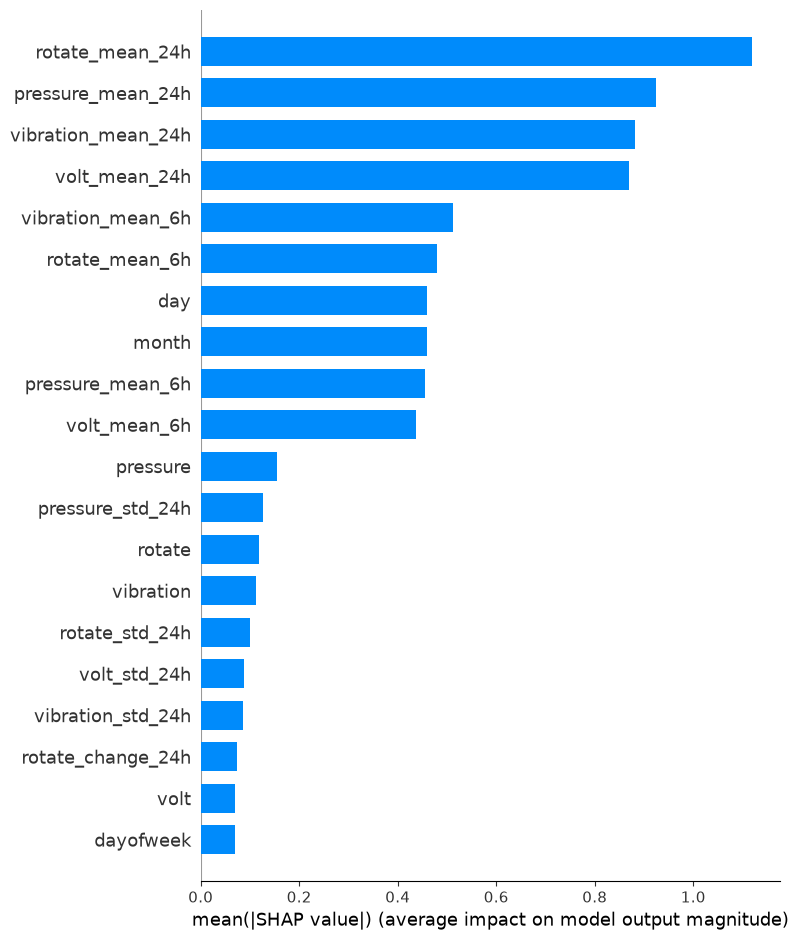

In [10]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

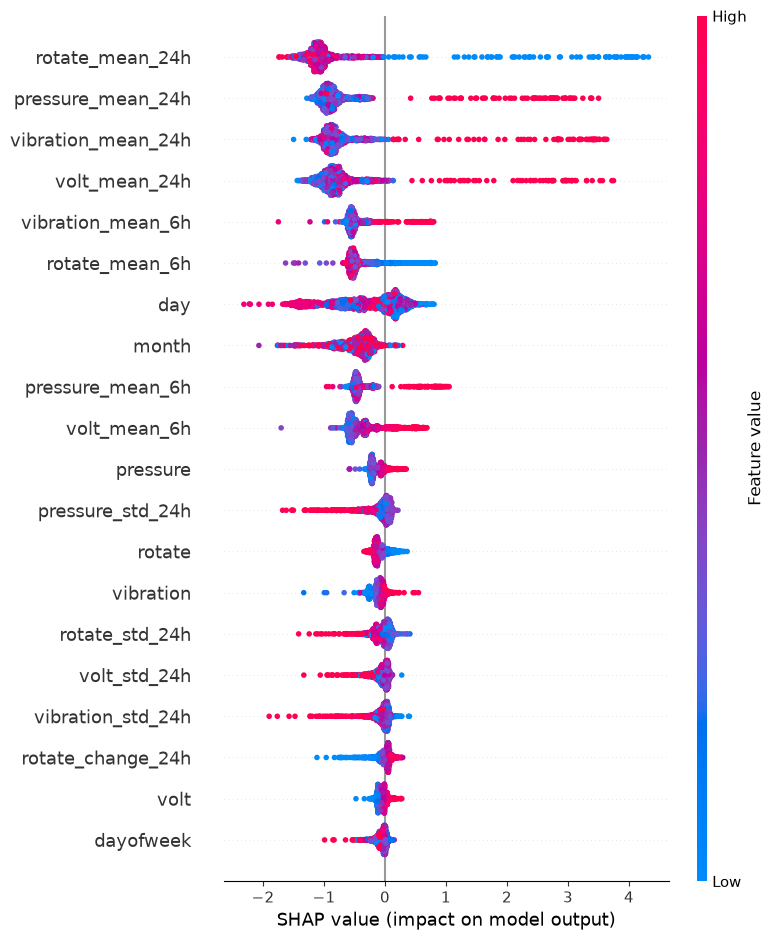

In [11]:
shap.summary_plot(
    shap_values,
    X_shap
)

In [12]:
# Pick an actual failure case from the test set
failure_indices = y_test[y_test == 1].index

idx = failure_indices[0]

print("Selected index:", idx)
print("Actual value:", y_test.loc[idx])

sample = X_test.loc[[idx]]

print("\nFeature values:")
display(sample.T)

Selected index: 700896
Actual value: 1

Feature values:


,700896
volt,157.018007
rotate,273.177119
pressure,87.803265
vibration,39.828670
hour,6.000000
day,20.000000
month,10.000000
dayofweek,1.000000
volt_mean_6h,171.964252
volt_std_6h,15.954059


In [15]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for this one prediction
sample_shap = explainer.shap_values(sample)

print("SHAP shape:", sample_shap.shape)

# Model probability
probability = model.predict_proba(sample)[0][1]

print("Predicted failure probability:", probability)
print("Actual:", y_test.loc[idx])

SHAP shape: (1, 32)
Predicted failure probability: 0.9637471
Actual: 1


Sample SHAP shape: (1, 32)


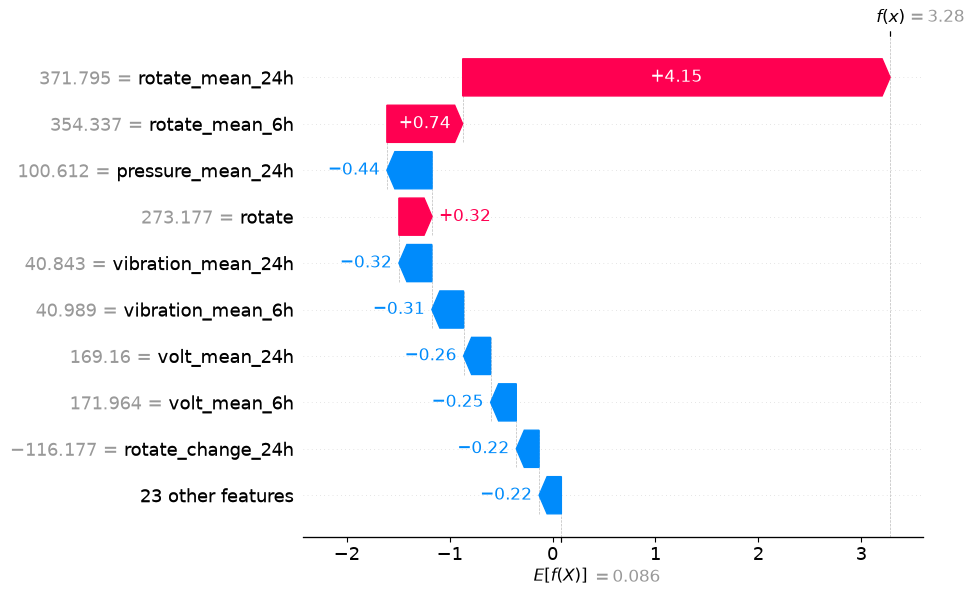

In [16]:
import shap
import matplotlib.pyplot as plt

# Use the loaded final 32-feature model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the selected sample
sample_shap = explainer.shap_values(sample)

print("Sample SHAP shape:", sample_shap.shape)

# Plot explanation
shap.waterfall_plot(
    shap.Explanation(
        values=sample_shap[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=feature_names
    )
)

In [17]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create folder
os.makedirs("saved_model_original/shap", exist_ok=True)

# Save SHAP values
np.save(
    "saved_model_original/shap/shap_values.npy",
    shap_values
)

# Save SHAP sample
X_shap.to_pickle(
    "saved_model_original/shap/X_shap.pkl"
)

# Save feature names
with open("saved_model_original/shap/shap_feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=4)

print("SHAP results saved successfully!")

SHAP results saved successfully!


In [18]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance.to_csv(
    "saved_model_original/shap/shap_feature_importance.csv",
    index=False
)

print("Top 10 SHAP features:")
print(shap_importance.head(10))

Top 10 SHAP features:
               feature  mean_abs_shap
22     rotate_mean_24h       1.120048
24   pressure_mean_24h       0.923342
26  vibration_mean_24h       0.881903
20       volt_mean_24h       0.869292
14   vibration_mean_6h       0.511379
10      rotate_mean_6h       0.479214
5                  day       0.459726
6                month       0.459511
12    pressure_mean_6h       0.455670
8         volt_mean_6h       0.436914


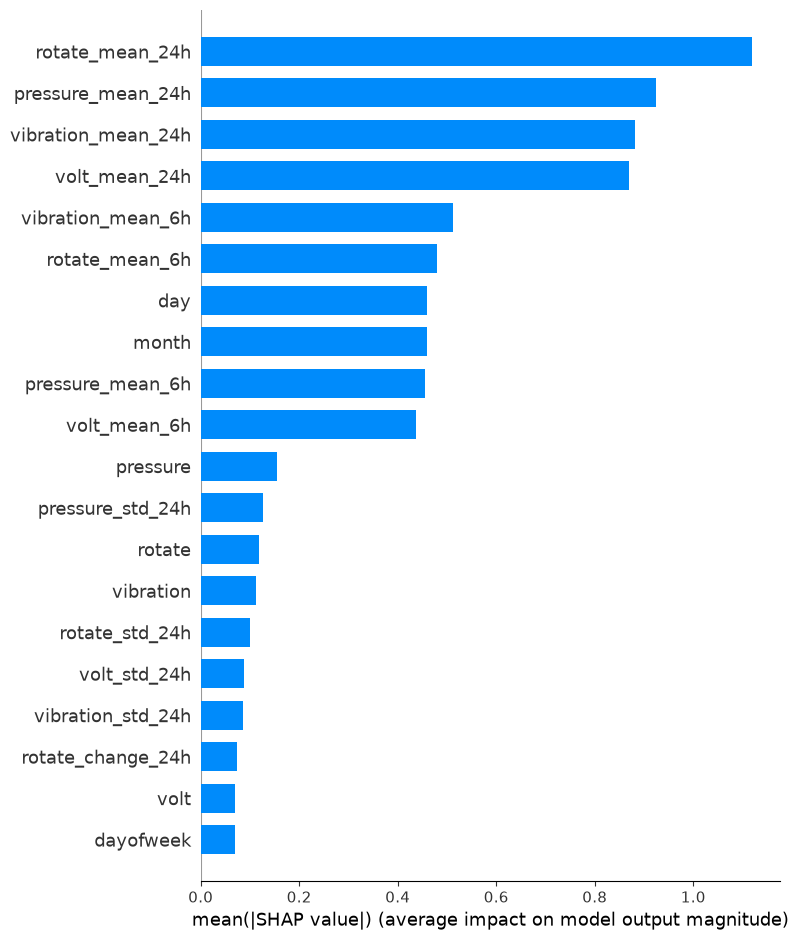

In [19]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    "saved_model_original/shap/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

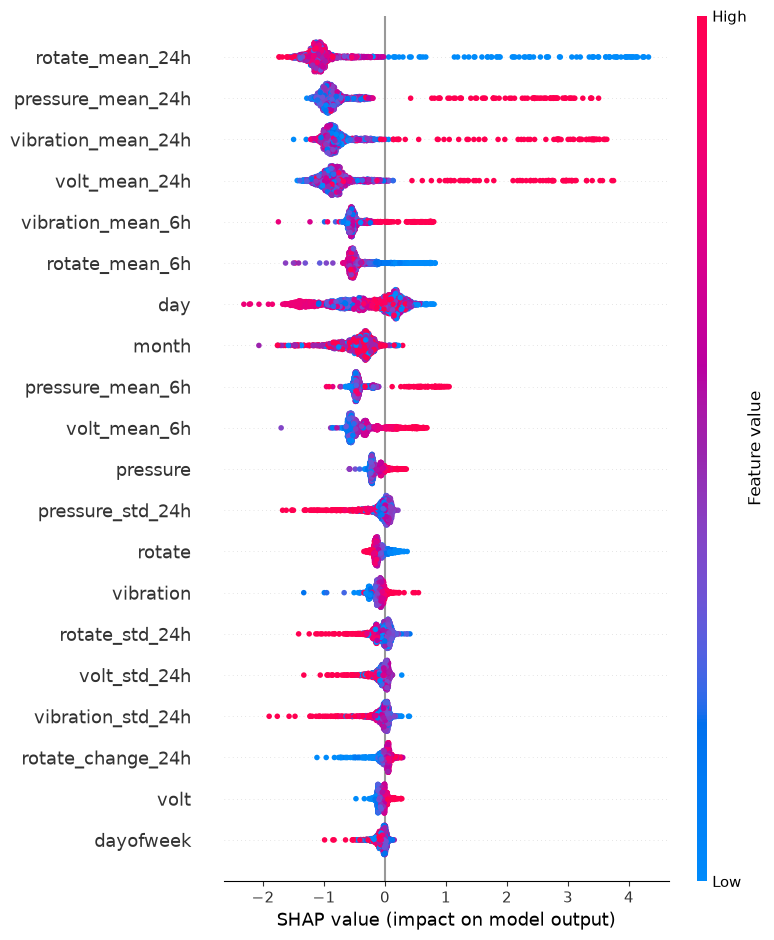

In [20]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig(
    "saved_model_original/shap/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

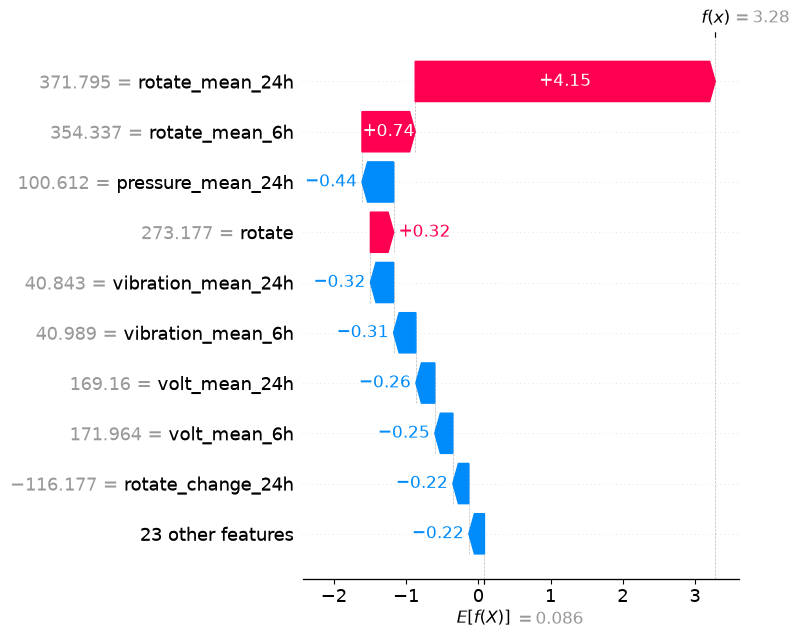

In [21]:
sample = X_test.loc[[700896]]

sample_shap = explainer(sample)

plt.figure()
shap.plots.waterfall(
    sample_shap[0],
    show=False
)

plt.tight_layout()
plt.savefig(
    "saved_model_original/shap/shap_waterfall_failure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [22]:
import os
import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd

# Create folder
os.makedirs("saved_model_original/shap", exist_ok=True)

# -----------------------------
# 1. Global SHAP bar plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig(
    "saved_model_original/shap/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# -----------------------------
# 2. SHAP beeswarm plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig(
    "saved_model_original/shap/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# -----------------------------
# 3. Local waterfall plot
# -----------------------------
plt.figure()

shap.plots.waterfall(
    shap.Explanation(
        values=sample_shap,
        base_values=explainer.expected_value,
        data=sample.iloc[0].values,
        feature_names=feature_names
    ),
    show=False
)

plt.tight_layout()
plt.savefig(
    "saved_model_original/shap/shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# -----------------------------
# 4. Save SHAP importance data
# -----------------------------
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance.to_csv(
    "saved_model_original/shap/shap_importance.csv",
    index=False
)

print("SHAP outputs saved successfully!")
print(shap_importance.head(10))

NameError: name 'shap_sample' is not defined

In [23]:
plt.figure()

shap.summary_plot(
    shap_values,
    sample,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()

IndexError: index 1190 is out of bounds for axis 0 with size 1

In [24]:
# Recreate the exact 2000-row SHAP sample
shap_sample = X_test_saved.iloc[:2000].copy()

print("SHAP sample shape:", shap_sample.shape)
print("SHAP values shape:", shap_values.shape)
print("Feature names:", len(feature_names))

SHAP sample shape: (2000, 32)
SHAP values shape: (2000, 32)
Feature names: 32


<Figure size 640x480 with 0 Axes>

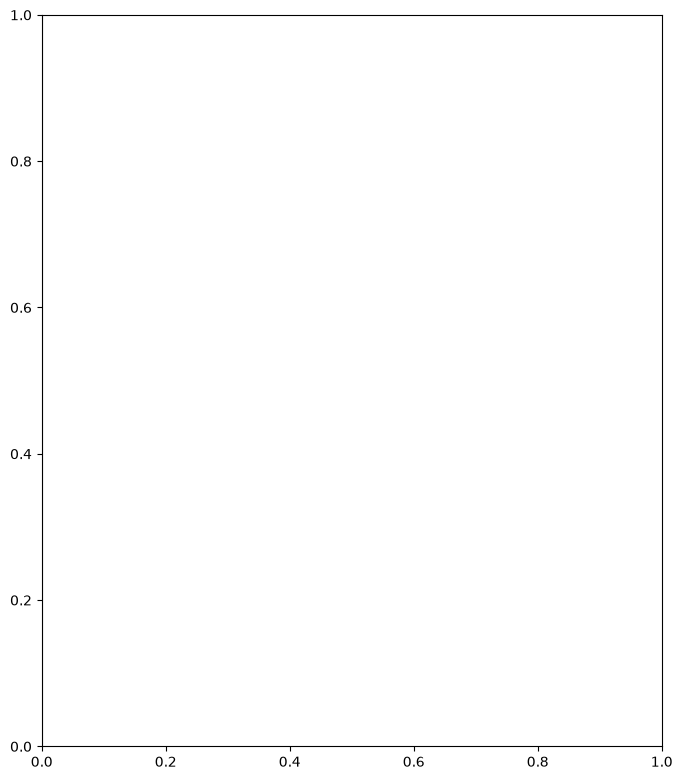

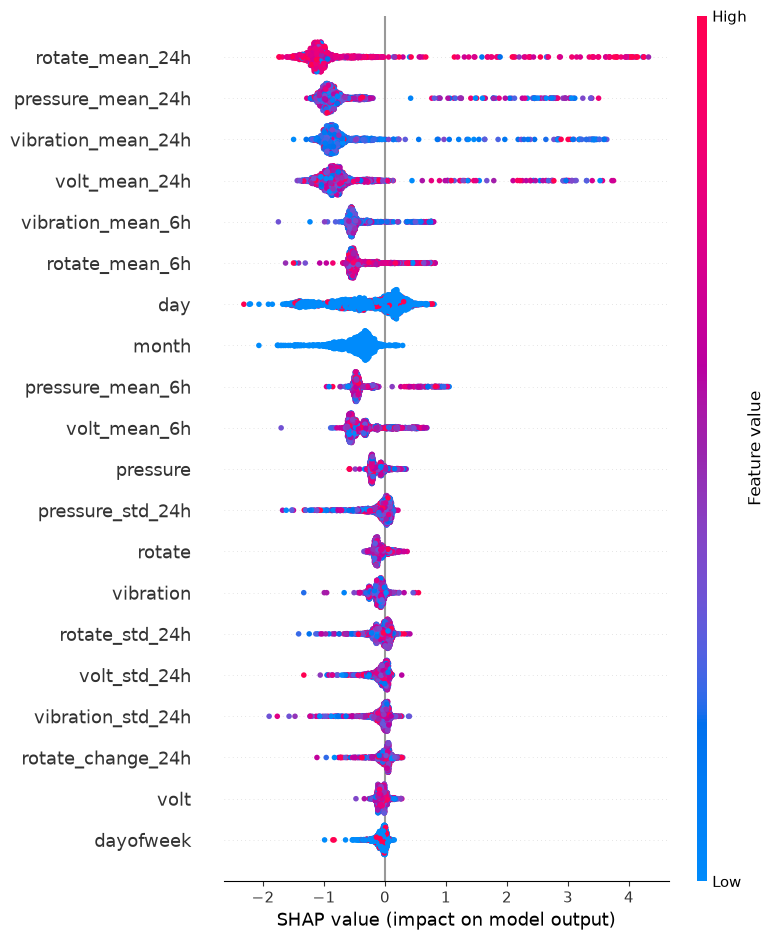

In [25]:
plt.figure()

shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()

In [6]:
import shap
import matplotlib.pyplot as plt

In [10]:
plt.figure()

shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names,
   plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()


NameError: name 'shap_values' is not defined

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt

plt.savefig("../shap/shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.close()

print("SHAP feature importance saved!")

SHAP feature importance saved!
